# Welcome to the Ribolog Tutorial

In [ ]:
install.packages("~/Downloads/Ribolog", repos = NULL, type = "source")

In [1]:
devtools::load_all("~/Downloads/Ribolog")

ℹ Loading Ribolog
Registered S3 method overwritten by 'gdata':
  method         from     
  reorder.factor DescTools



### Important notes before you start: </b>
#### 1. Ribolog has a modular structure which allows for a user to start their workflow at a stage that is comptible with their data structure. Thus, choose the module based on the data that you have, and your goal out of the analysis.
#### 2. Module 1 and 2 are absolutely essential in order to use any functionalities from Module 3-6.
#### 3. We highly recommend using module 3 for transcript-level QC and sample quality checks before proceeding to TER testing in Module 4.

| Module | Data Type Required     |  Aim |
| :-----------: | :-----------: | :-----------: |
| Module 1 | Aligned, Indexed, and sorted .bam files | Codon-level QC, Pre-processing |
| Module 2 | Reads list and P-site offset from Module 1 | Removing stalling bias, RNA read counts, Ribosome dwell time analysis  | 
| Module 3 | Counts Matrices from Module 2 | Transcript-level QC, Batch effect check | 
| Module 4 | Counts Matrices from Module 2  | Differential translational efficiency testing  | 
| Module 5 | Testing results from Module 4  | Testing the empirical null distribution  | 
| Module 6 | Counts Matrices from Module 2  | ORF usage and Stop Codon Readthrough  | 

# Module 1: Pre-Processing and CELP Bias

## Step 1.1 Load pre-provided annotations or load your own

Ribolog can automatically load the annotations and fasta files of the following organisms:
- Arabidopsis
- Fly
- Human
- Maize
- Mouse
- Rat
- Worm (C Elegans)
- Yeast
- Zebrafish

If you are working with an organism that is not in this list, please see the 'Load your own annotation' section.

In [2]:
annotation <- Ribolog::human_annotation

In [3]:
cdna_fasta <- Ribolog::human_cdna

In [4]:
mapper <- Ribolog::human_id_mapper

### Load your own annotation (Optional but recommended if you chose a different annotation for your alignment)

<b> Run the python script on your downloaded fasta file from Ensembl Biomart </b>

- To download a formatted fasta reference file for Humans, click [here.](https://drive.google.com/file/d/1r9W2Ll3qMPIHMr0vy_Ixr641_7OJTBL3/view?usp=sharing)
- To download a formatted fasta reference file for Mouse, click [here.](https://drive.google.com/file/d/1Kk5dhdIXWK-GO2pdAPJvX9PeXQGSA4gr/view?usp=sharing)
- The command below will run on the mart_export.txt file and create 3 more txt files (cDNA_longest_CDS.txt, annotation.txt and mapper.txt) within the same directory.

```bash
python3 Biomart_cDNA_fasta_to_rW_annotation_and_reheadered_longest_CDS_cDNA_fasta_v2.py Human.GRCh38.96.gtf cDNA_longest_CDS.txt annotation.txt mapper.txt
```

### Check the imported annotation table

In [5]:
head(annotation)

transcript,l_tr,l_utr5,l_cds,l_utr3
<chr>,<int>,<int>,<int>,<int>
ENST00000003084,6132,132,4443,1557
ENST00000001146,4732,204,1539,2989
ENST00000002125,2184,48,1326,810
ENST00000000233,1032,88,543,401
ENST00000002829,3607,289,2358,960
ENST00000001008,3715,170,1380,2165


## Step 1.2 Convert the bam files to a reads_list object

In [6]:
list.files('~/Downloads/fastq/rpf') # All bam files

[1] "CN34_r1_rpf.bam"     "CN34_r1_rpf.bam.bai" "CN34_r2_rpf.bam"    
 [4] "CN34_r2_rpf.bam.bai" "LM1a_r1_rpf.bam"     "LM1a_r1_rpf.bam.bai"
 [7] "LM1a_r2_rpf.bam"     "LM1a_r2_rpf.bam.bai" "LM2_r1_rpf.bam"     
[10] "LM2_r1_rpf.bam.bai"  "LM2_r2_rpf.bam"      "LM2_r2_rpf.bam.bai" 
[13] "MDA_r1_rpf.bam"      "MDA_r1_rpf.bam.bai"  "MDA_r2_rpf.bam"     
[16] "MDA_r2_rpf.bam.bai"

Run riboWlatz to estimate the most likely ribosomal p-site offsets for each read length group. Combine this information with the reads_list object produced by bamtolist_rW to create a reads_psite_list object. Each data frame in this list corresponds to one sample and contains the distance of the reads p-sites from the start and stop codons. It also shows whether each p-site falls in the 5’ UTR, CDs or 3’ UTR region.

<b> Notes: </b>
- Read through the output and make sure that Ribolog approves the result of each output
- The average expected time taken for the bam to list converstion is <b> 25 seconds per bam file </b> although it make vary based on the number of reads.

In [7]:
reads_list <- Ribolog::bamtolist_rW(bamfolder='~/Downloads/fastq/rpf', annotation=annotation)

Reading CN34_r1_rpf.bam
Input reads: 6.402 M
0.000 M  (0.001 %) reads removed: exceeding indel_threshold.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.429 M  (6.703 %) reads removed: mapping on negative strand.
Output reads: 5.973 M
Done! CN34_r1_rpf.bam has been loaded as CN34_r1_rpf 

Reading CN34_r2_rpf.bam
Input reads: 7.357 M
36.000 (< 0.001 %) reads removed: exceeding indel_threshold.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.821 M  (11.165 %) reads removed: mapping on negative strand.
Output reads: 6.535 M
Done! CN34_r2_rpf.bam has been loaded as CN34_r2_rpf 

Reading LM1a_r1_rpf.bam
Input reads: 2.749 M
0.000 M  (0.001 %) reads removed: exceeding indel_threshold.
Great! All reads' reference transcript IDs were found in the annotation table. No reads removed.
0.278 M  (10.098 %) reads removed: mapping on negative strand.
Output reads: 2.471 M
Done! LM1a_r1_rpf.bam has b

#### NOTE: Please pay attention to the 'Output reads:' line for each sample above. A good analysis requires >= 1.5 million reads per sample.


- Read through the contents of reads list and make sure to match all the input bam files

In [8]:
names(reads_list)

[1] "CN34_r1_rpf" "CN34_r2_rpf" "LM1a_r1_rpf" "LM1a_r2_rpf" "LM2_r1_rpf" 
[6] "LM2_r2_rpf"  "MDA_r1_rpf"  "MDA_r2_rpf"

- Each sample name is indexed on the reads_list object as shown below

In [9]:
head(reads_list$CN34_r1_rpf)

transcript,end5,end3,length,cds_start,cds_stop
<fct>,<int>,<int>,<int>,<dbl>,<int>
ENST00000003084,2334,2348,15,133,4575
ENST00000003084,2335,2350,16,133,4575
ENST00000001146,117,132,16,205,1743
ENST00000001146,121,136,16,205,1743
ENST00000001146,122,138,17,205,1743
ENST00000001146,122,138,17,205,1743


## Step 1.3 Create p-site offset and a reads_psite_list object

<b> Notes: </b>
1. The function below will process each bam file and create the p-site offsets
2. The average time taken for p-site offset creation is 6-7 seconds per bam file.

In [10]:
psite_offset <- psite_rW(reads_list)

processing CN34_r1_rpf
best offset: 12 nts from the 5' end
processing CN34_r2_rpf
best offset: 12 nts from the 5' end
processing LM1a_r1_rpf
best offset: 12 nts from the 5' end
processing LM1a_r2_rpf
best offset: 12 nts from the 5' end
processing LM2_r1_rpf
best offset: 12 nts from the 5' end
processing LM2_r2_rpf
best offset: 12 nts from the 5' end
processing MDA_r1_rpf
best offset: 12 nts from the 5' end
processing MDA_r2_rpf
best offset: 12 nts from the 5' end


<b> Notes: </b>
1. The function below will process each p-site offset and create the reads_psite_list.
2. The average time taken for p-site offset creation is 5-6 seconds per bam file.

In [11]:
reads_psite_list <- Ribolog::psite_info_rW(reads_list, psite_offset) # Will process all bam files

processing CN34_r1_rpf
1. adding p-site position
2. adding transcript region
processing CN34_r2_rpf
1. adding p-site position
2. adding transcript region
processing LM1a_r1_rpf
1. adding p-site position
2. adding transcript region
processing LM1a_r2_rpf
1. adding p-site position
2. adding transcript region
processing LM2_r1_rpf
1. adding p-site position
2. adding transcript region
processing LM2_r2_rpf
1. adding p-site position
2. adding transcript region
processing MDA_r1_rpf
1. adding p-site position
2. adding transcript region
processing MDA_r2_rpf
1. adding p-site position
2. adding transcript region


In [12]:
head(reads_psite_list$CN34_r1_rpf)

transcript,end5,psite,end3,length,cds_start,cds_stop,psite_from_start,psite_from_stop,psite_region
<fct>,<int>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<chr>
ENST00000003084,2334,2340,2348,15,133,4575,2207,-2235,cds
ENST00000003084,2335,2344,2350,16,133,4575,2211,-2231,cds
ENST00000001146,117,126,132,16,205,1743,-79,-1617,5utr
ENST00000001146,121,130,136,16,205,1743,-75,-1613,5utr
ENST00000001146,122,131,138,17,205,1743,-74,-1612,5utr
ENST00000001146,122,131,138,17,205,1743,-74,-1612,5utr


## Step 1.4 Print QC Plots

The reads_psite_list object produced by psite_info_rW is the key input used by the CELP method. Before proceeding to CELP correction, it is recommended to print out some QC plots, browse patterns and decide what read lengths will be included for further analysis. Chosen read lengths must be relatively abundant across samples and show proper periodicity in the CDS region. The code for several useful plot types and two example plots are included here.

### Read length distribution plots

<b> By default, the functions prints the visualisations inline for each bam file </b>

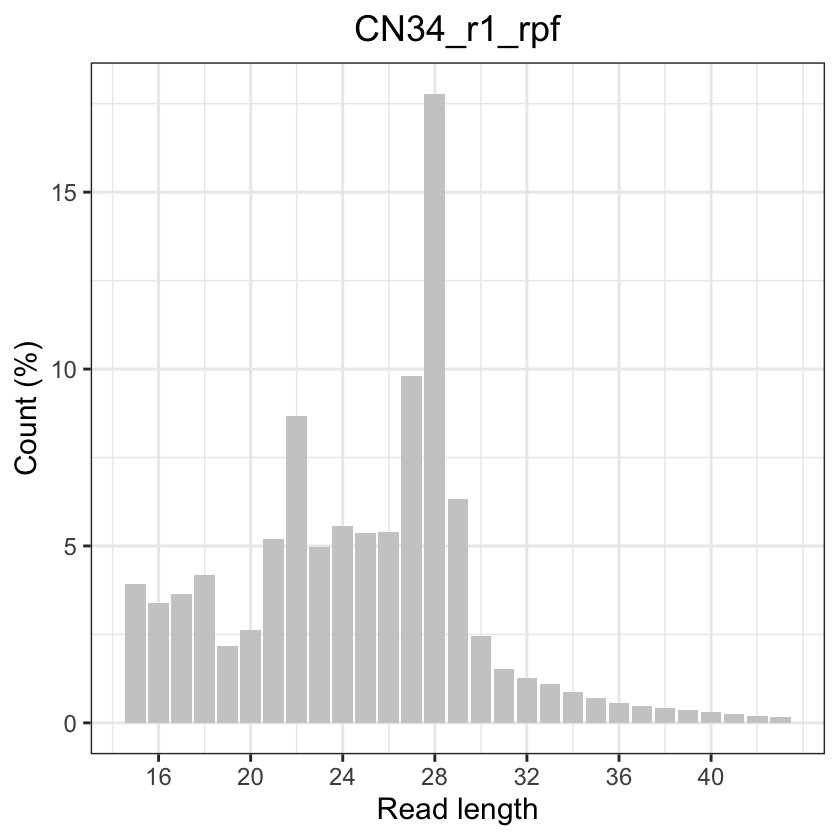

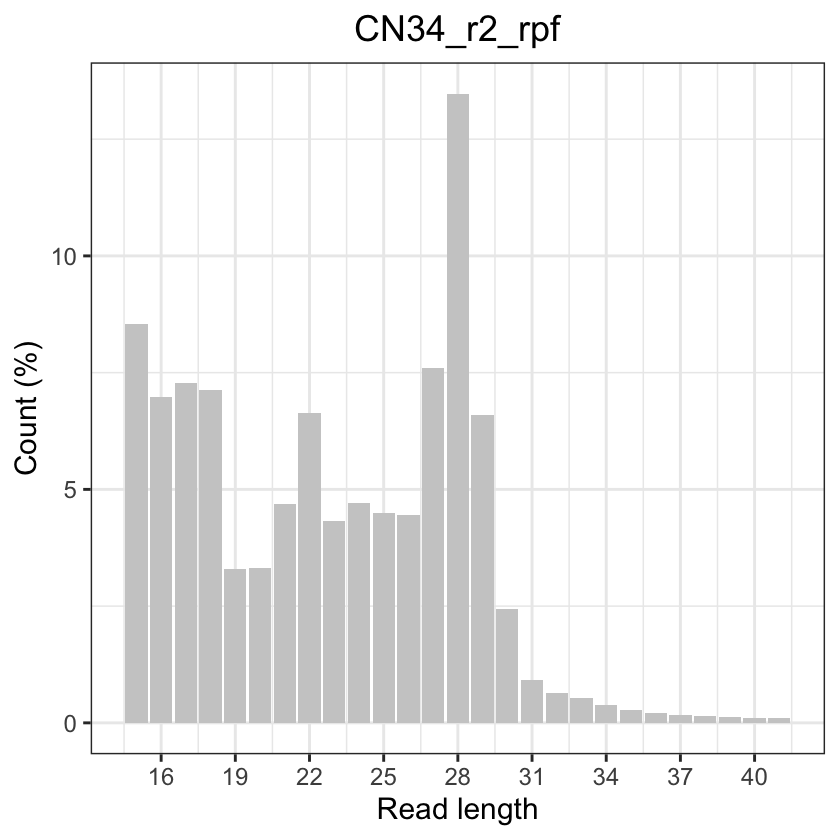

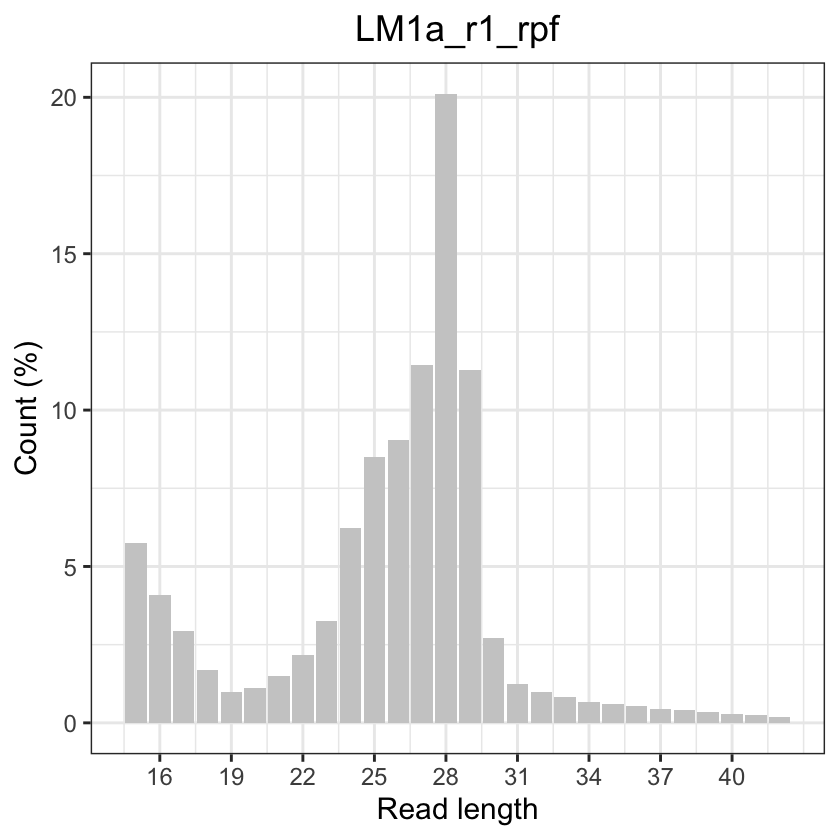

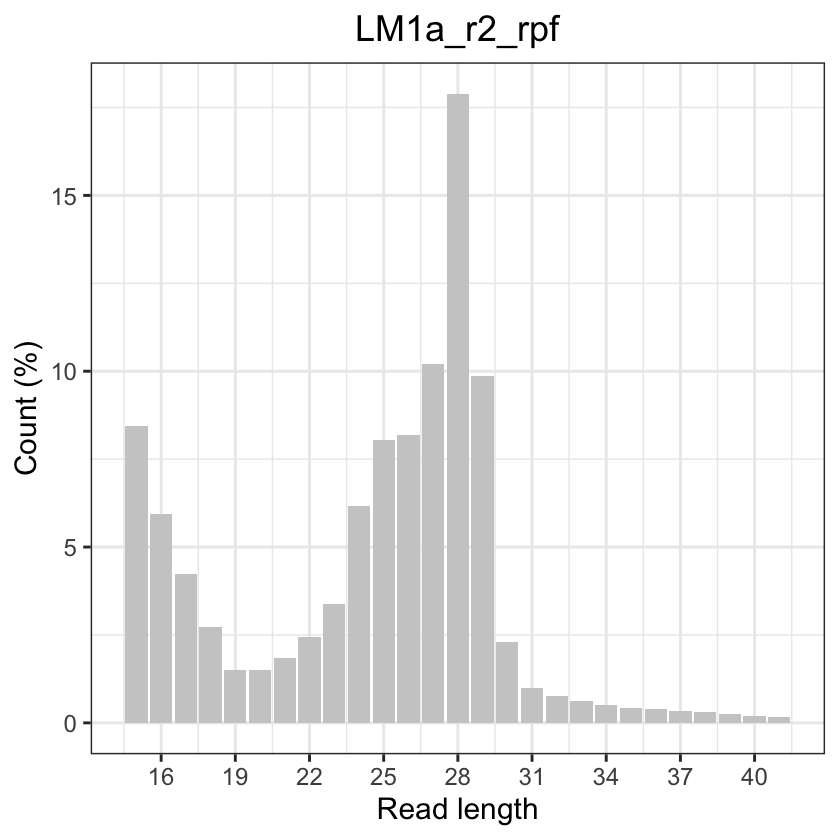

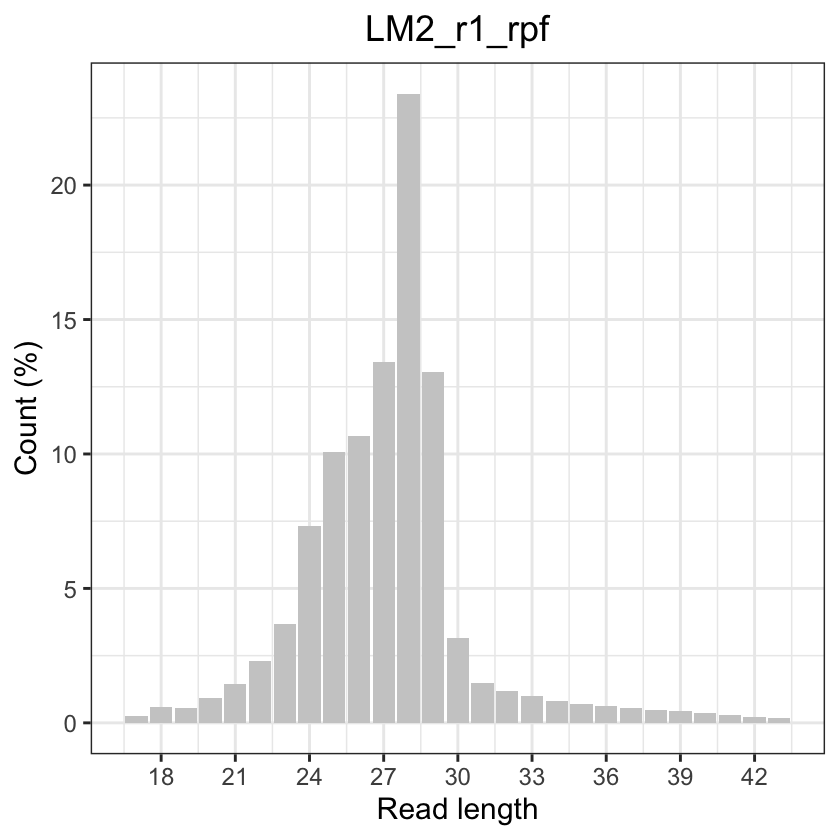

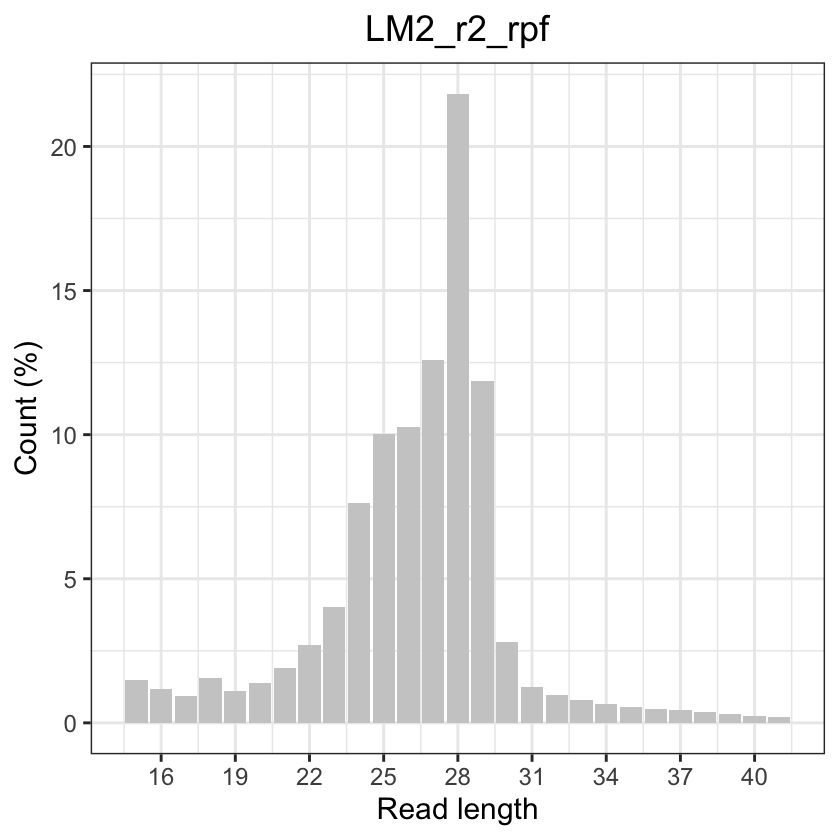

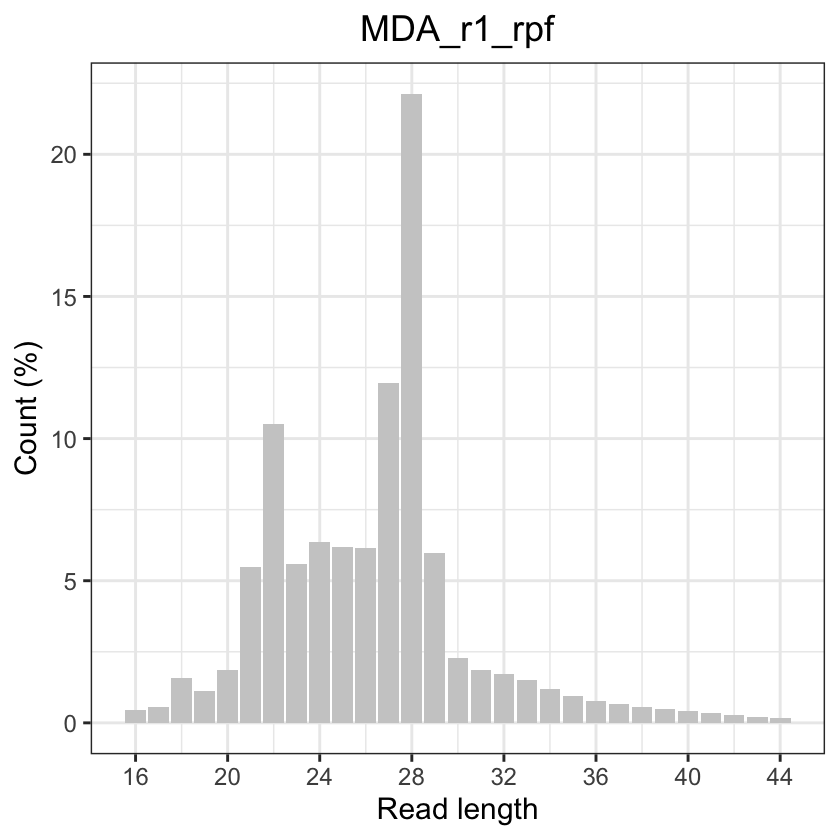

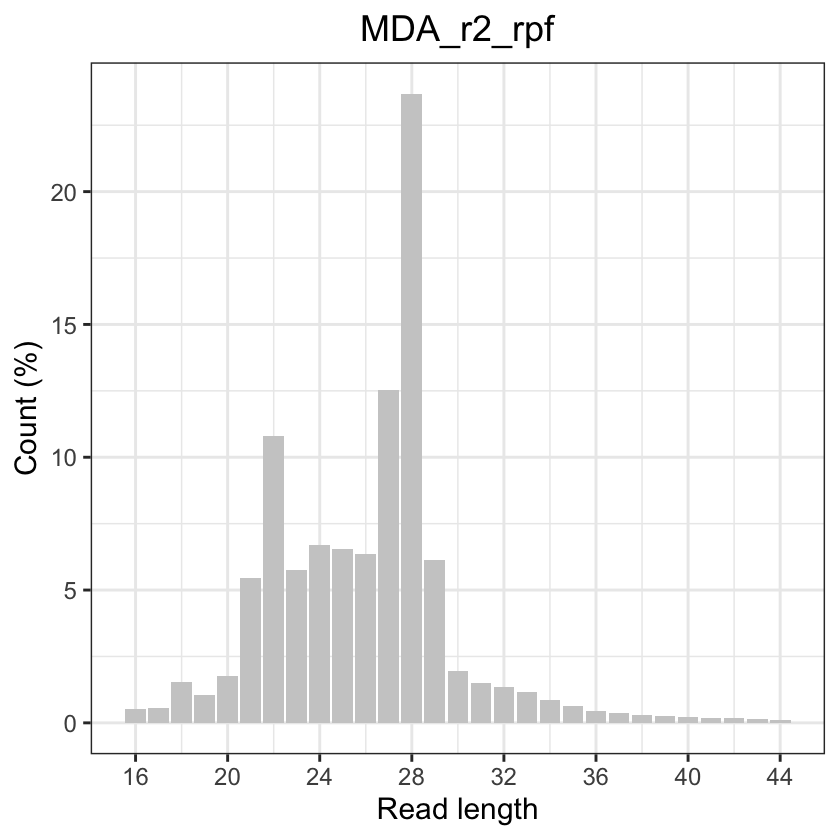

In [13]:
print_read_ldist(reads_list)

<b> You can also export the visualisations to a PDF by specifying a output PDF name. </b>

In [14]:
Ribolog::print_read_ldist(reads_list, outfile='reads_length_distribution.pdf')

[1] "PDF (reads_length_distribution.pdf) created and saved"

### Visualizing Periodicity Length

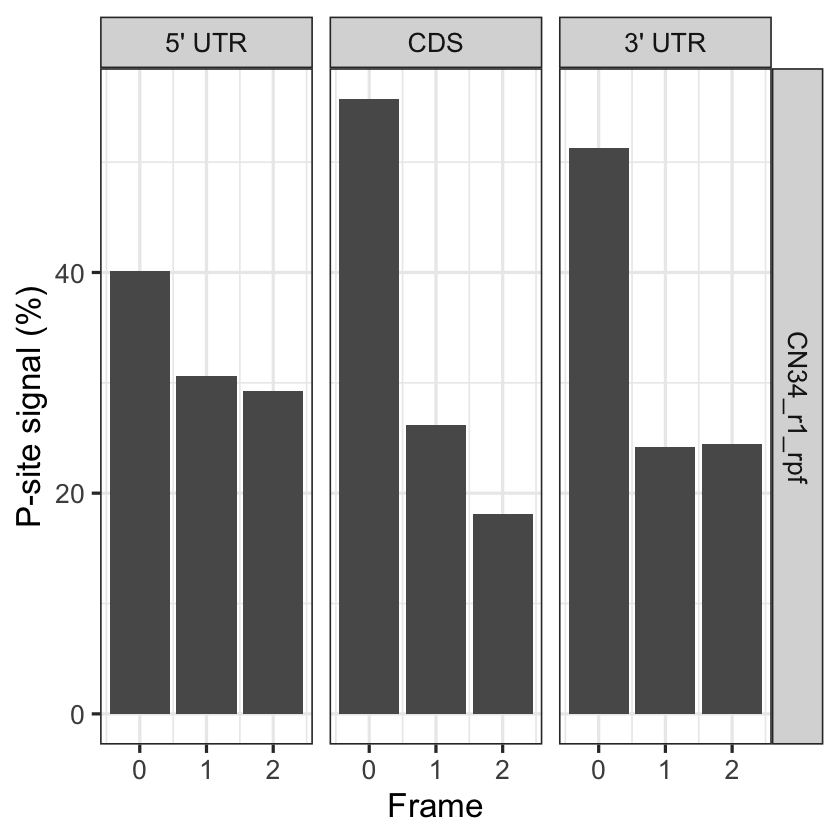

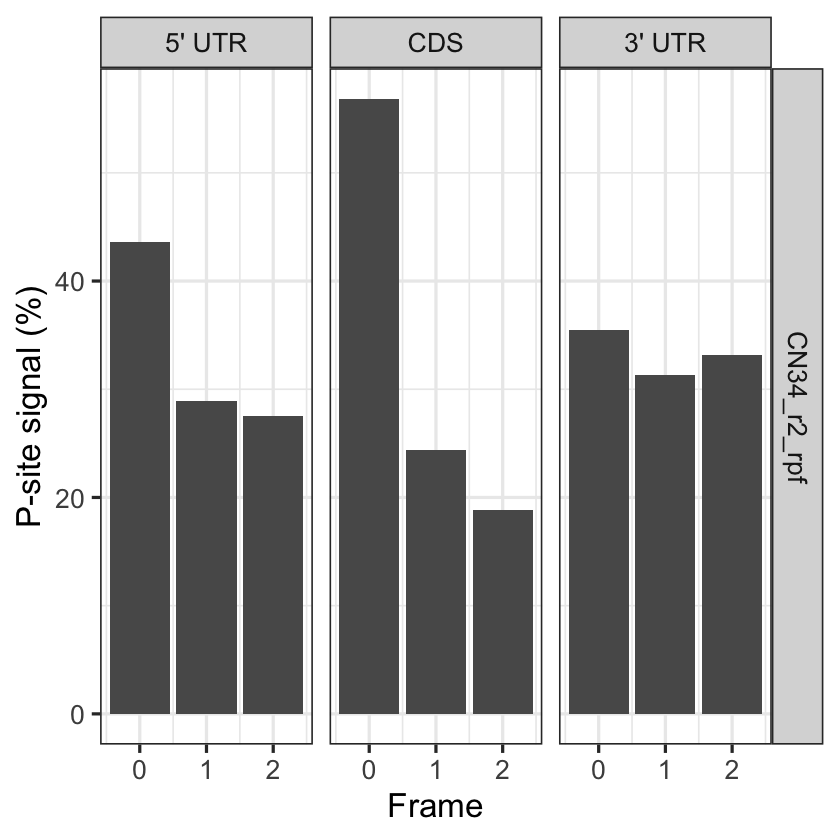

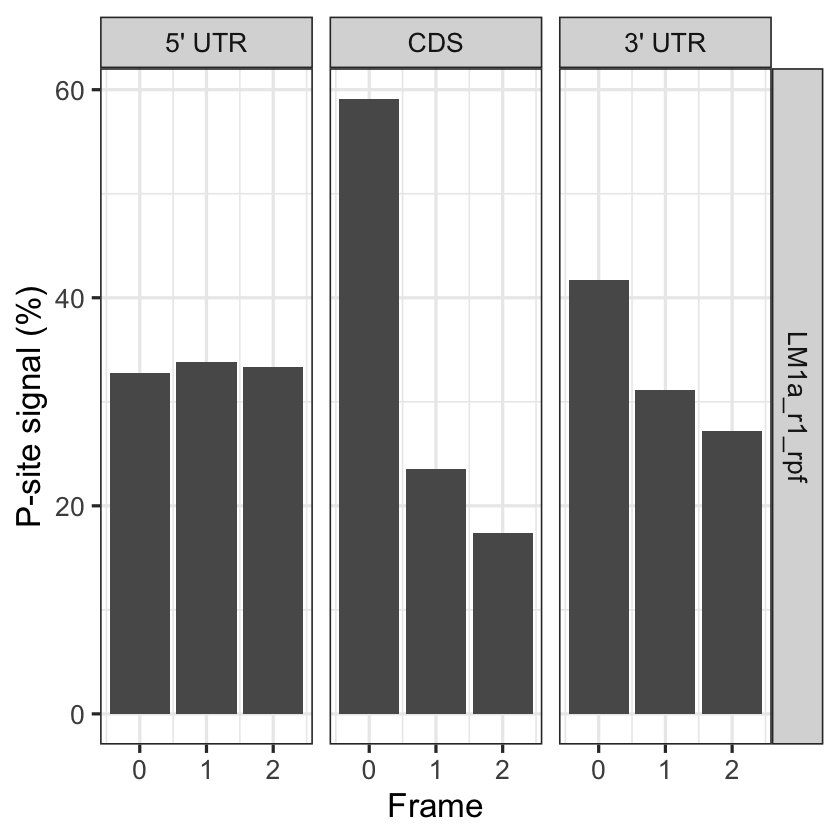

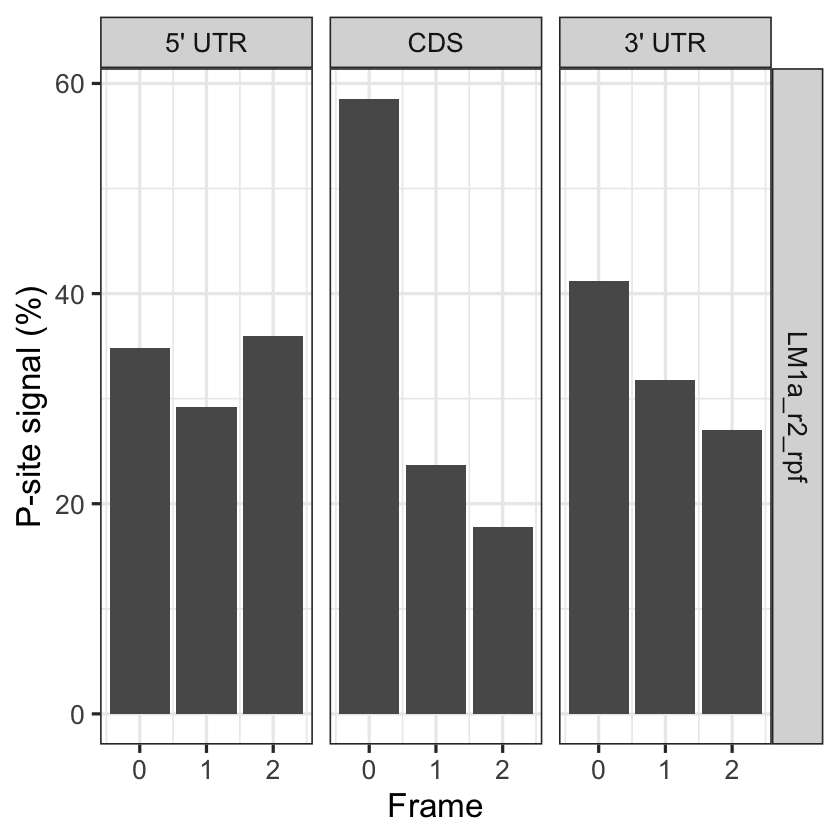

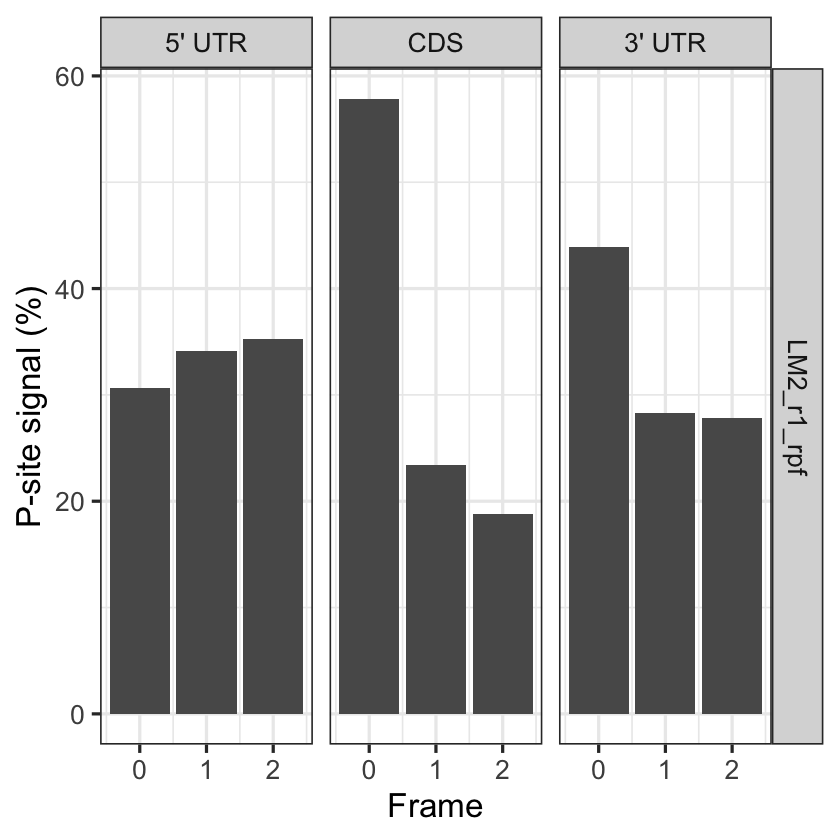

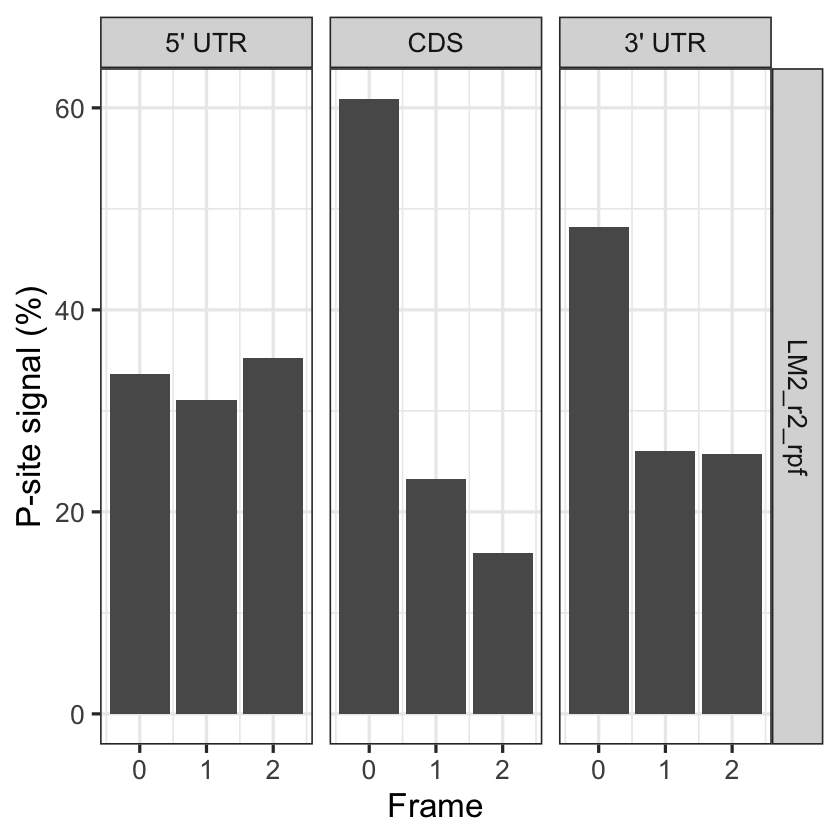

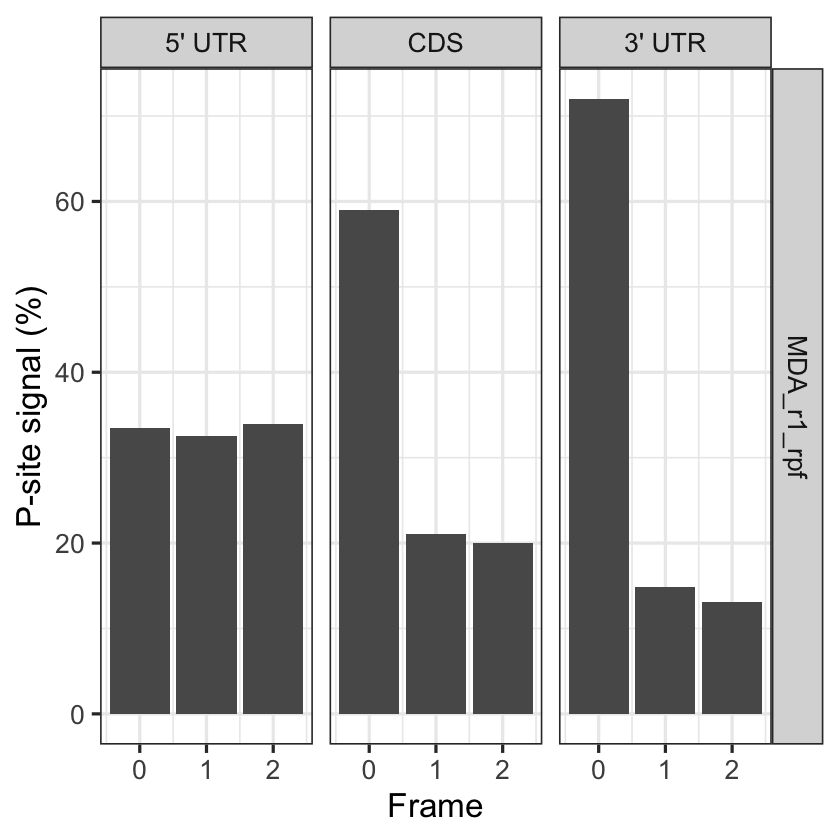

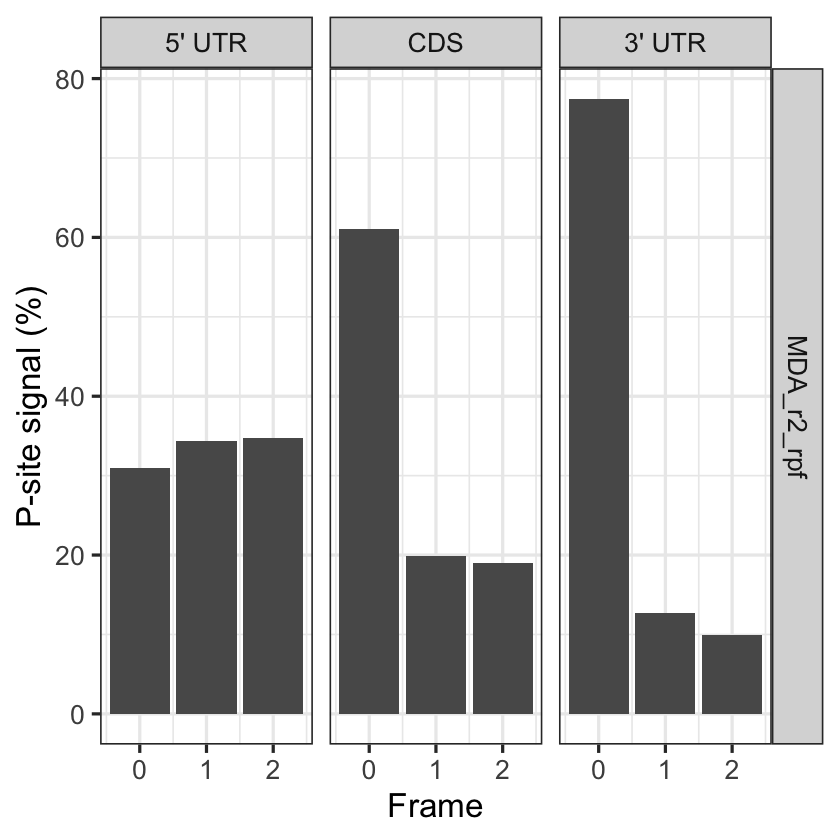

In [15]:
print_period_region(reads_psite_list)

### Visualizing Periodicity Length by Region

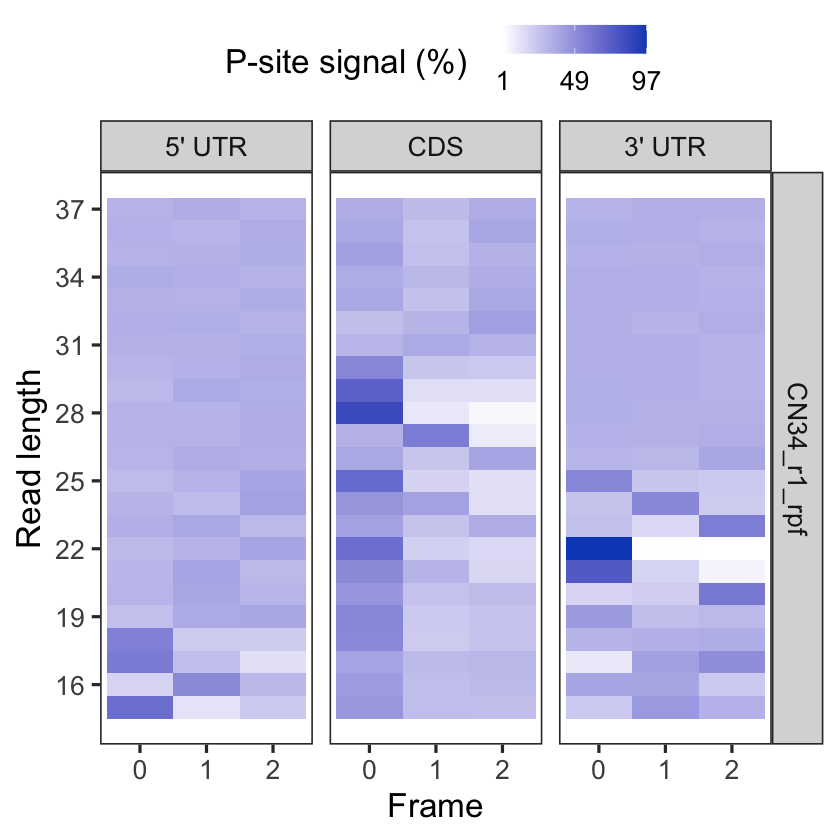

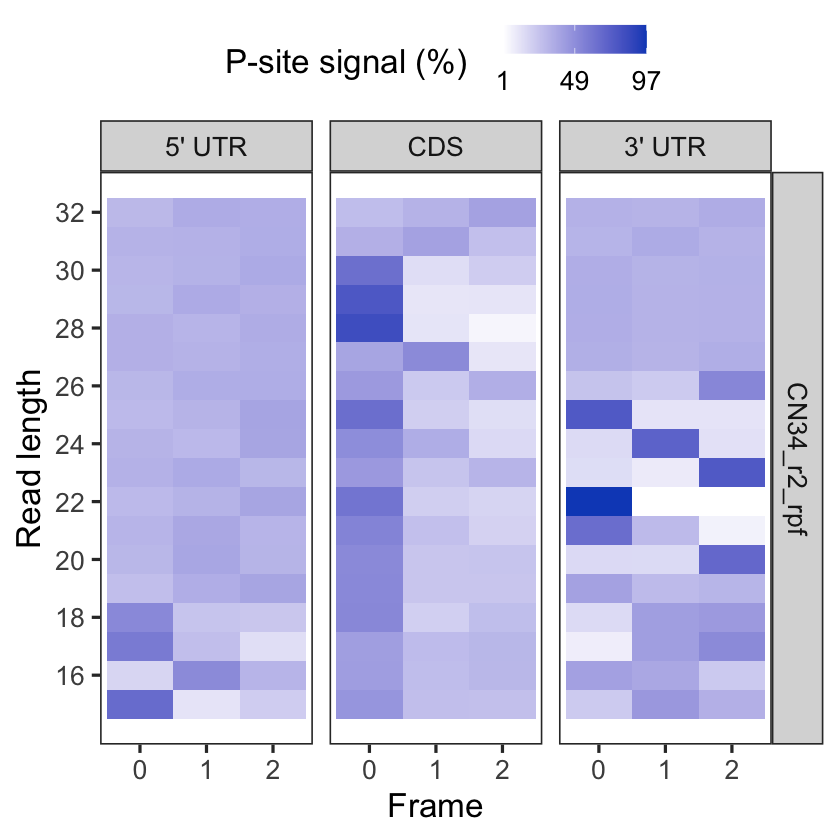

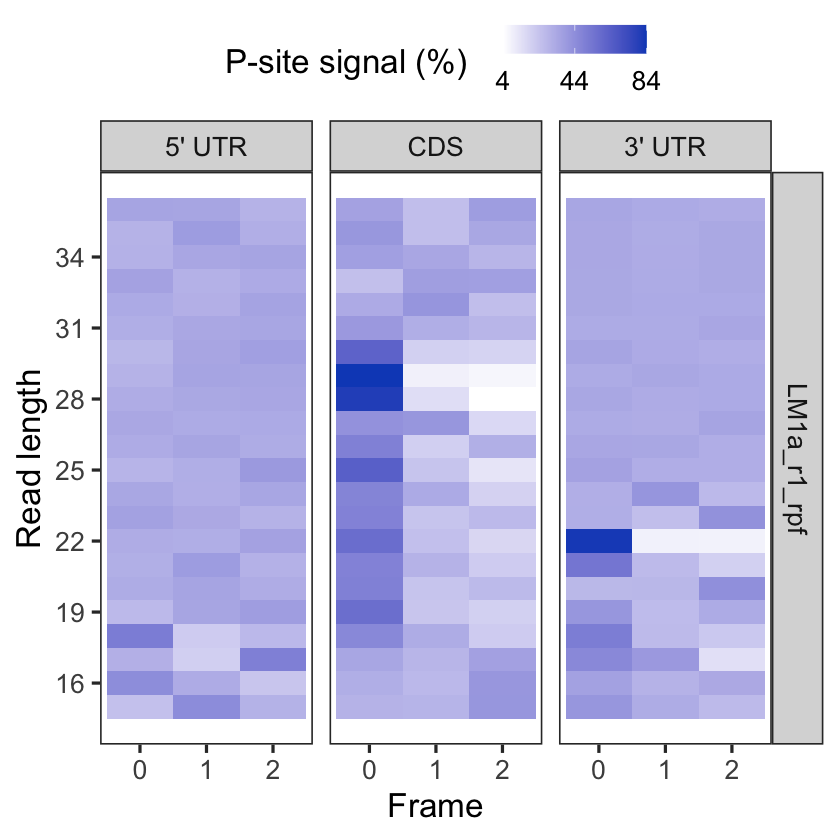

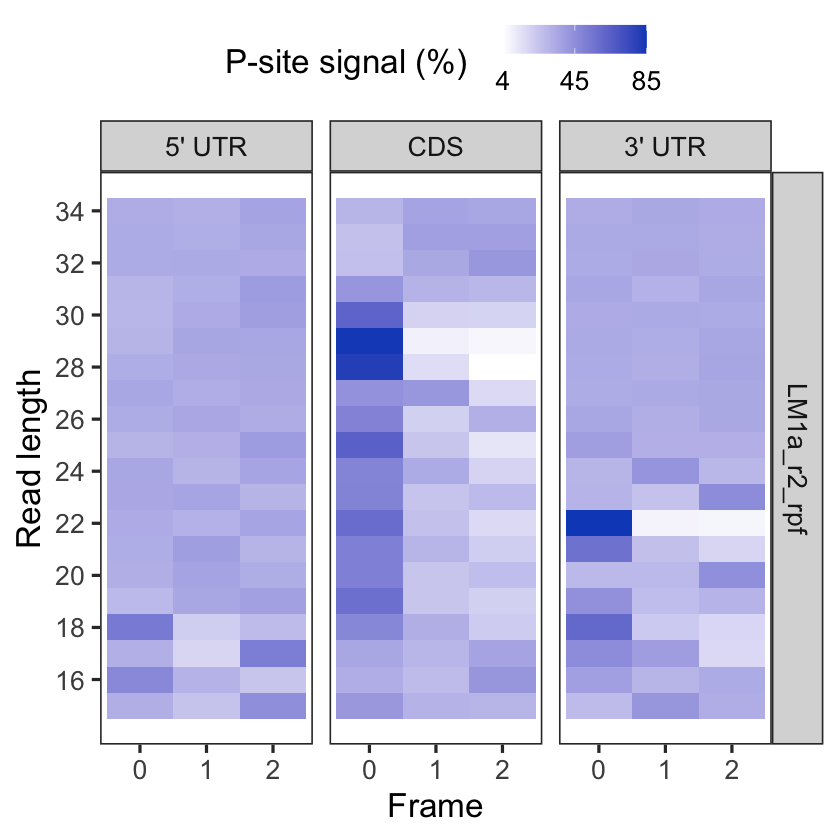

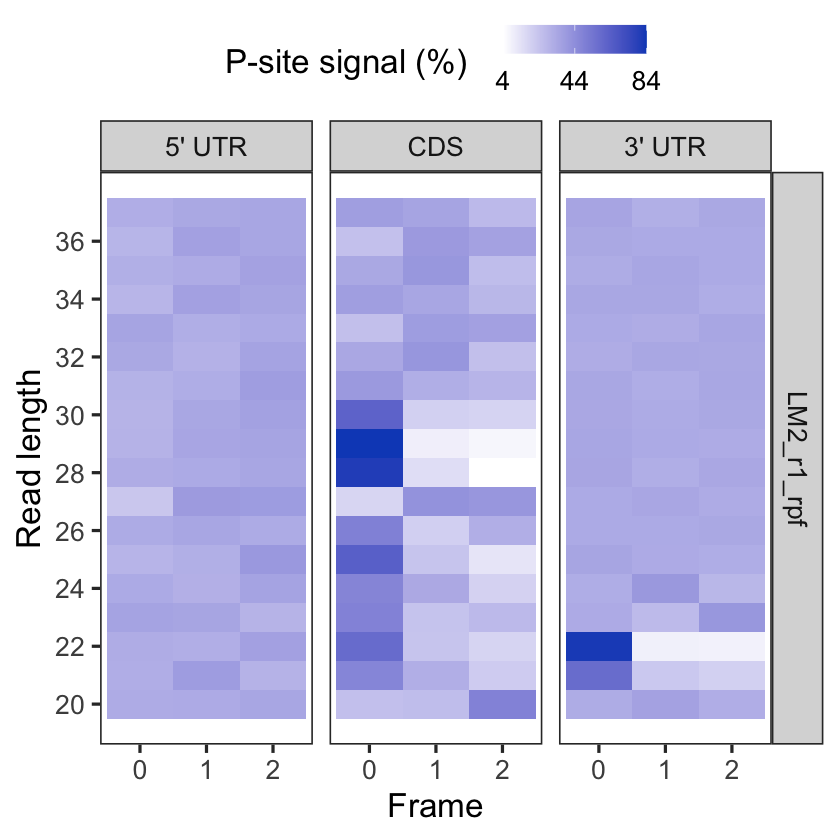

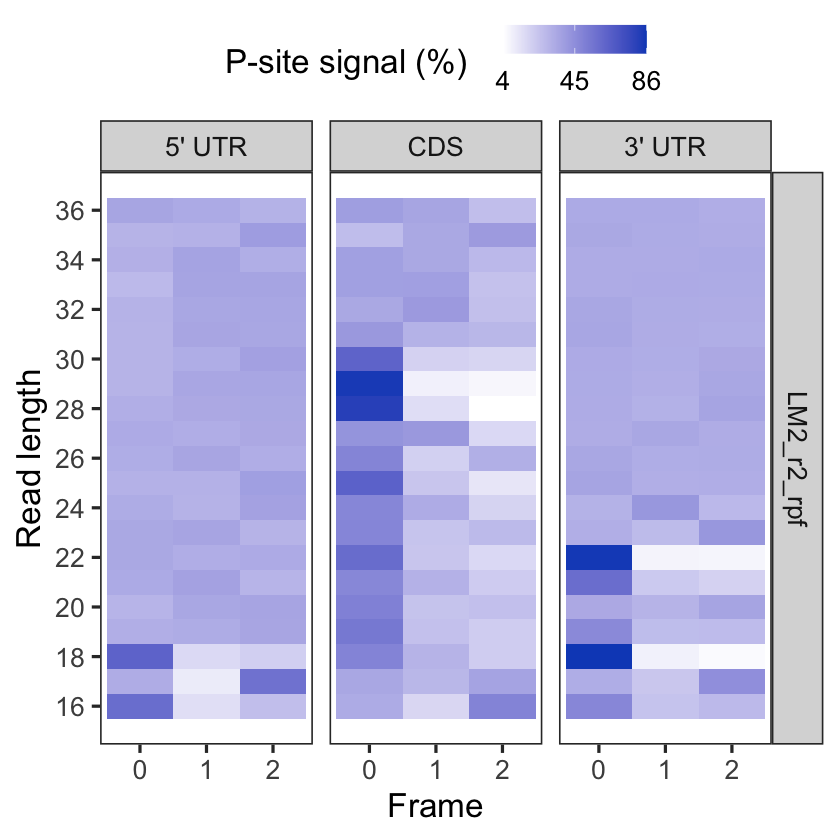

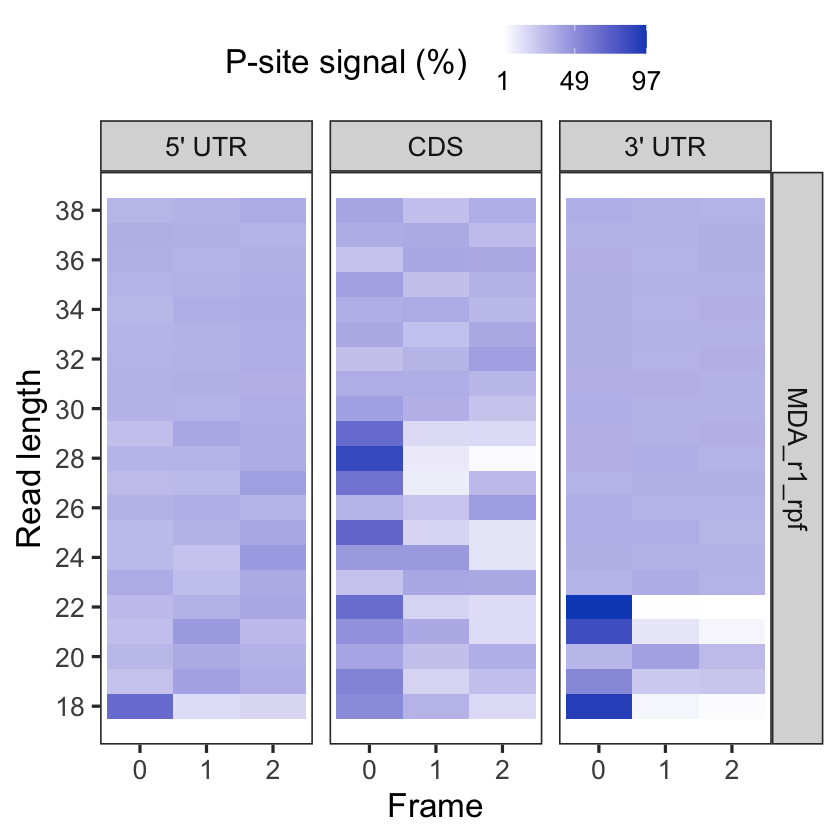

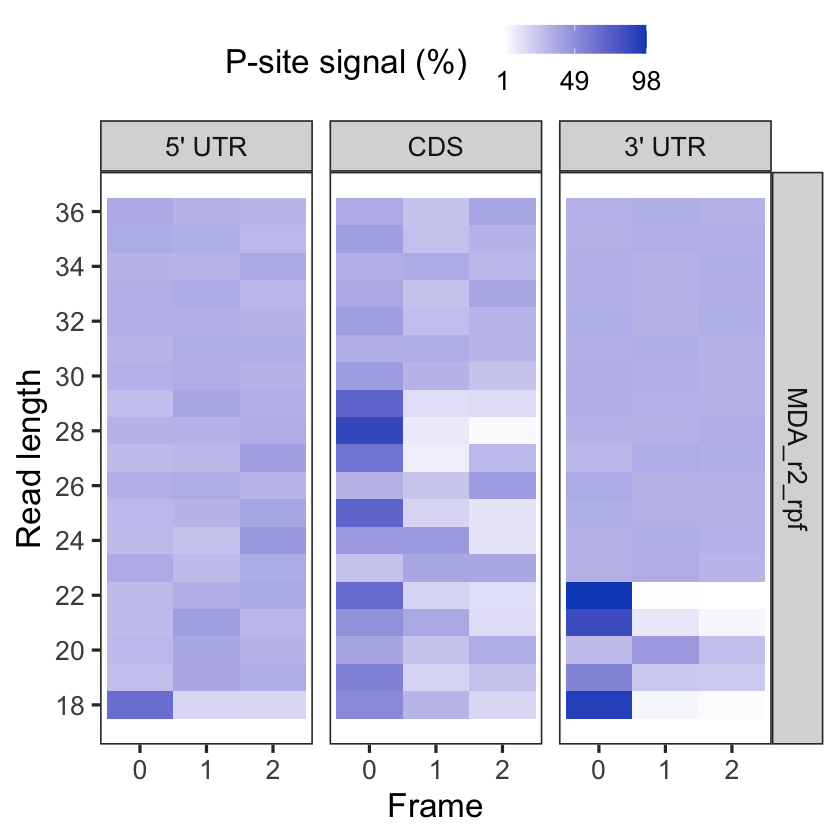

In [16]:
print_period_region_length(reads_psite_list)

- Save the output as a PDF

In [17]:
Ribolog::print_period_region_length(reads_psite_list, outfile='periodicity_by_length_region2.pdf')

[1] "PDF (periodicity_by_length_region2.pdf) created and saved"

## Step 1.5: Get codon read counts

The psite_to_codon_count function aggregates read p-site data to obtain codon read counts.

In [18]:
# Decide your range of the length of the reads that you want to move forward with. We choose 24-32
l_range <- c(24:32)

- The average run time for the processing of codon counts is ~ 5 mins.

<b> NOTE: </b> You can specify the actual cdna_fasta object or specify a path to the fasta file. The function will process it accordingly.

In [19]:
tr_codon_read_count <- Ribolog::psite_to_codon_count(reads_psite_list,
                                                     length_range = l_range, 
                                                     annotation, 
                                                     fasta_file = cdna_fasta)

## Step 1.6: Load your sample attributes / metadata

- Here is an example of what the metadata looks like for our test samples
- It is important to use the option 'stringsAsFactors=TRUE' when you load your CSV to make sure that the text is treated as a covariate before running the regression analysis

In [20]:
sample_attributes <- read.csv("~/Downloads/sample_metadata.csv", header = TRUE, stringsAsFactors=TRUE)

In [21]:
sample_attributes

sample_name,read_type,lung_metastasis,cell_line,replicate_no,replicate_name,cell_line_origin
<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>
CN34_r1_rna,RNA,N,CN34,1,CN34_r1,CN34
CN34_r2_rna,RNA,N,CN34,2,CN34_r2,CN34
LM1a_r1_rna,RNA,Y,LM1a,1,LM1a_r1,CN34
LM1a_r2_rna,RNA,Y,LM1a,2,LM1a_r2,CN34
LM2_r1_rna,RNA,Y,LM2,1,LM2_r1,MDA
LM2_r2_rna,RNA,Y,LM2,2,LM2_r2,MDA
MDA_r1_rna,RNA,N,MDA,1,MDA_r1,MDA
MDA_r2_rna,RNA,N,MDA,2,MDA_r2,MDA
CN34_r1_rpf,RPF,N,CN34,1,CN34_r1,CN34


# Ribolog Module 2: RPF / RNA counts prep, normalization, and filtering before analysis

## Step 2.1: (VERY ESSENTIAL STEP) Calculate codon stalling bias and correct RPF transript counts

### Calculate CELP Bias

- The CELP_bias function computes codon-level bias coefficients and corrects the ribosome profiling counts accordingly.
- This step takes about ~5-10 mins

In [22]:
tr_codon_bias_coeff_loess_corrected_count <- Ribolog::CELP_bias(tr_codon_read_count)

### Visualize Translational Bias for different transcripts

The function visualize_CELP plots codon-level observed (upward black bars) and corrected (downward purple bars) read counts and the bias coefficient (red line) along the transcript. This allows visual inspection of the prominent bias positions and a comparison of read count heterogeneity along the transcript before and after CELP bias correction.

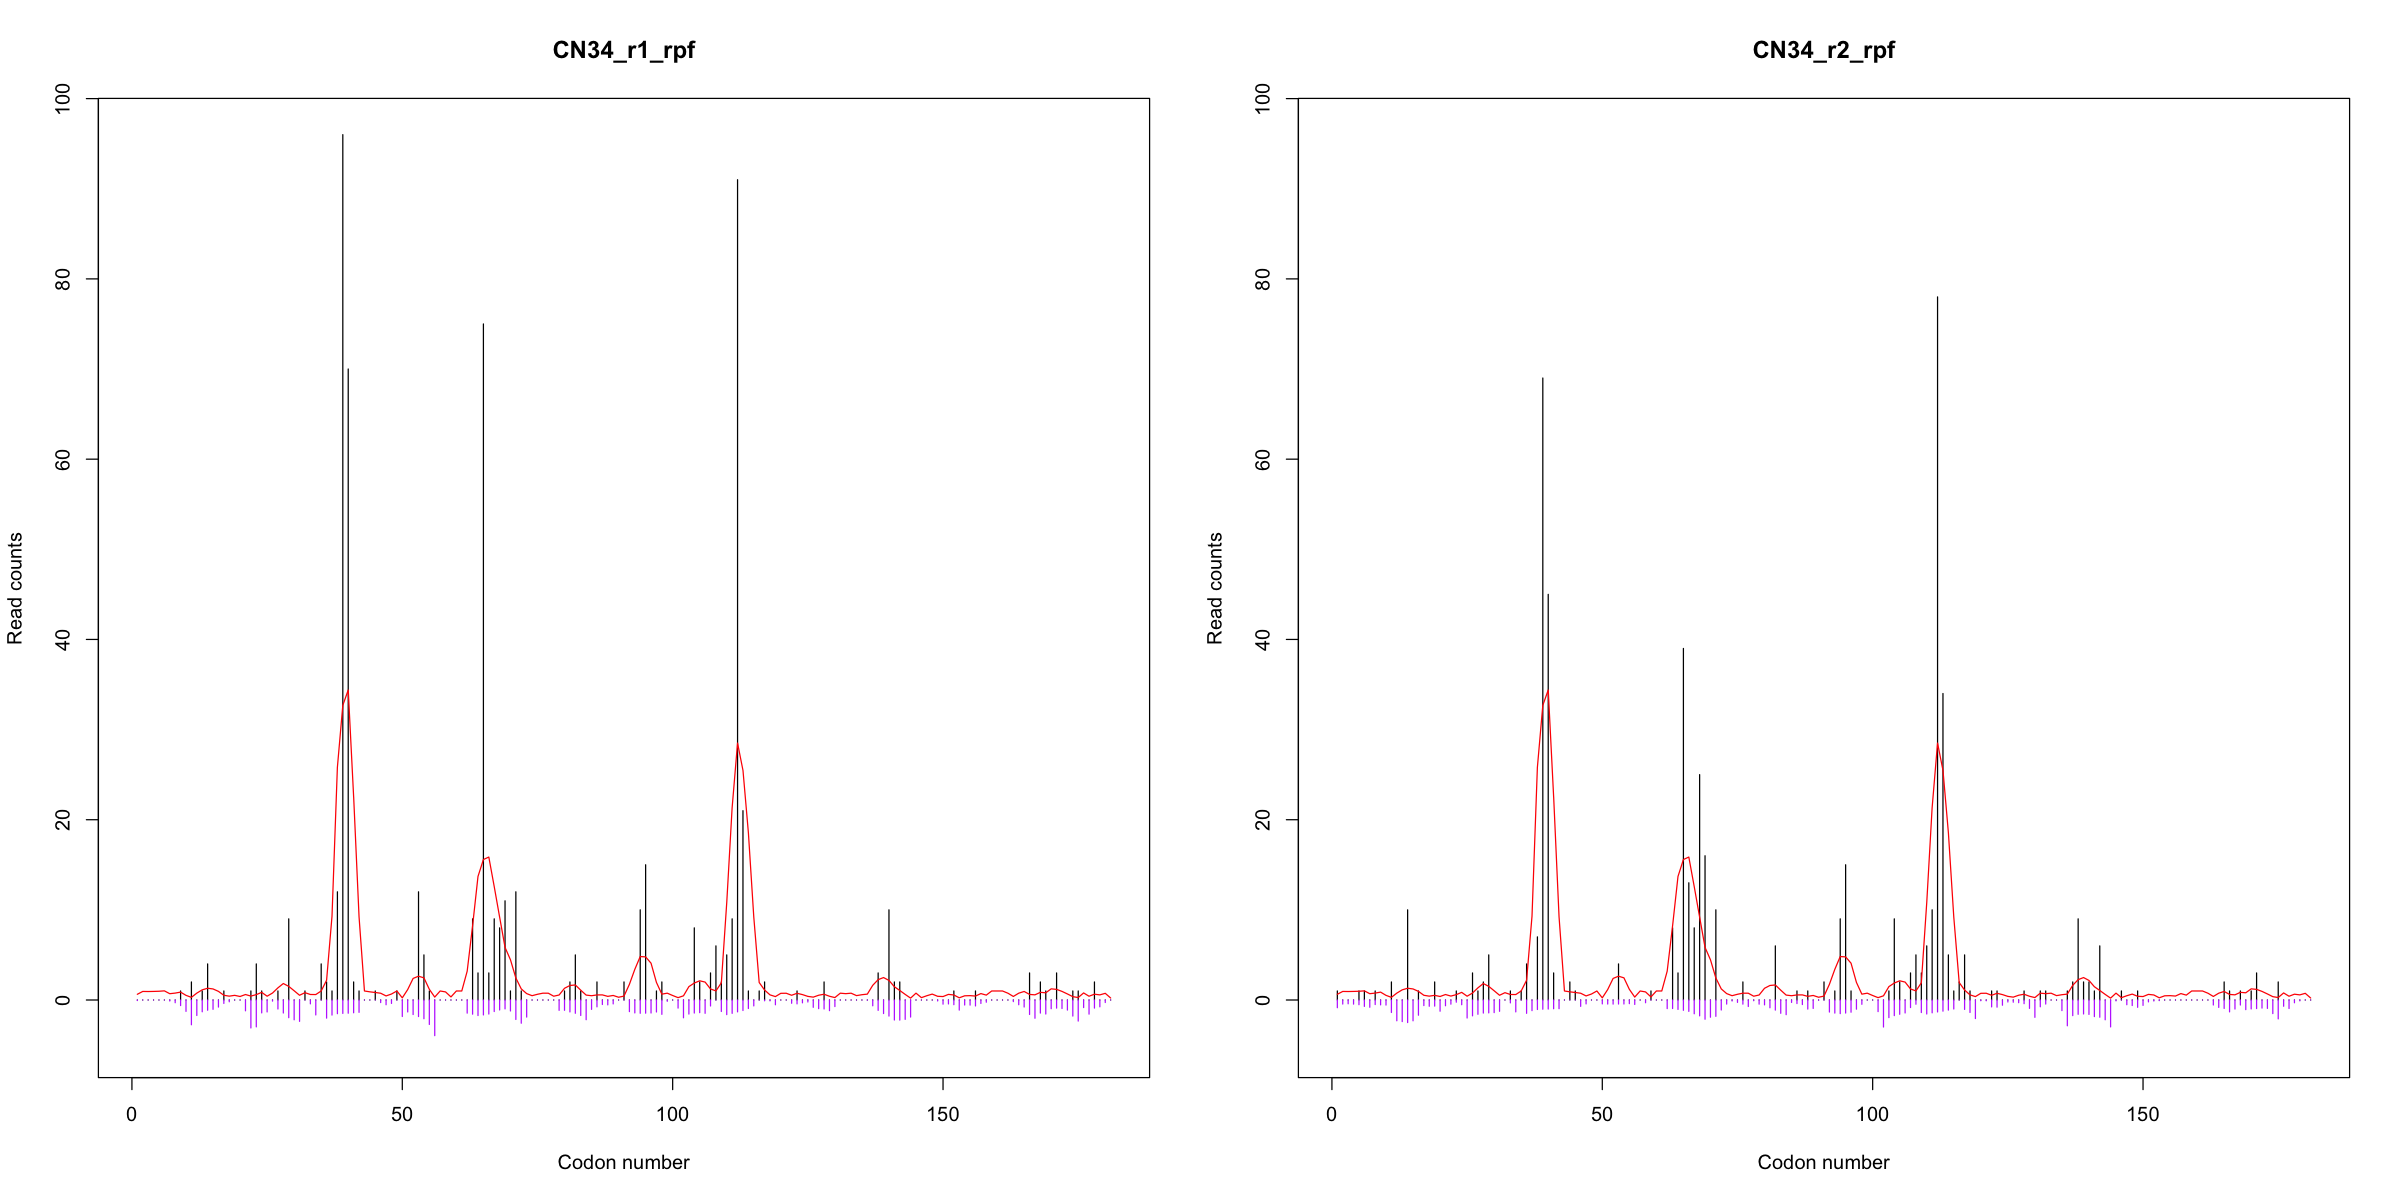

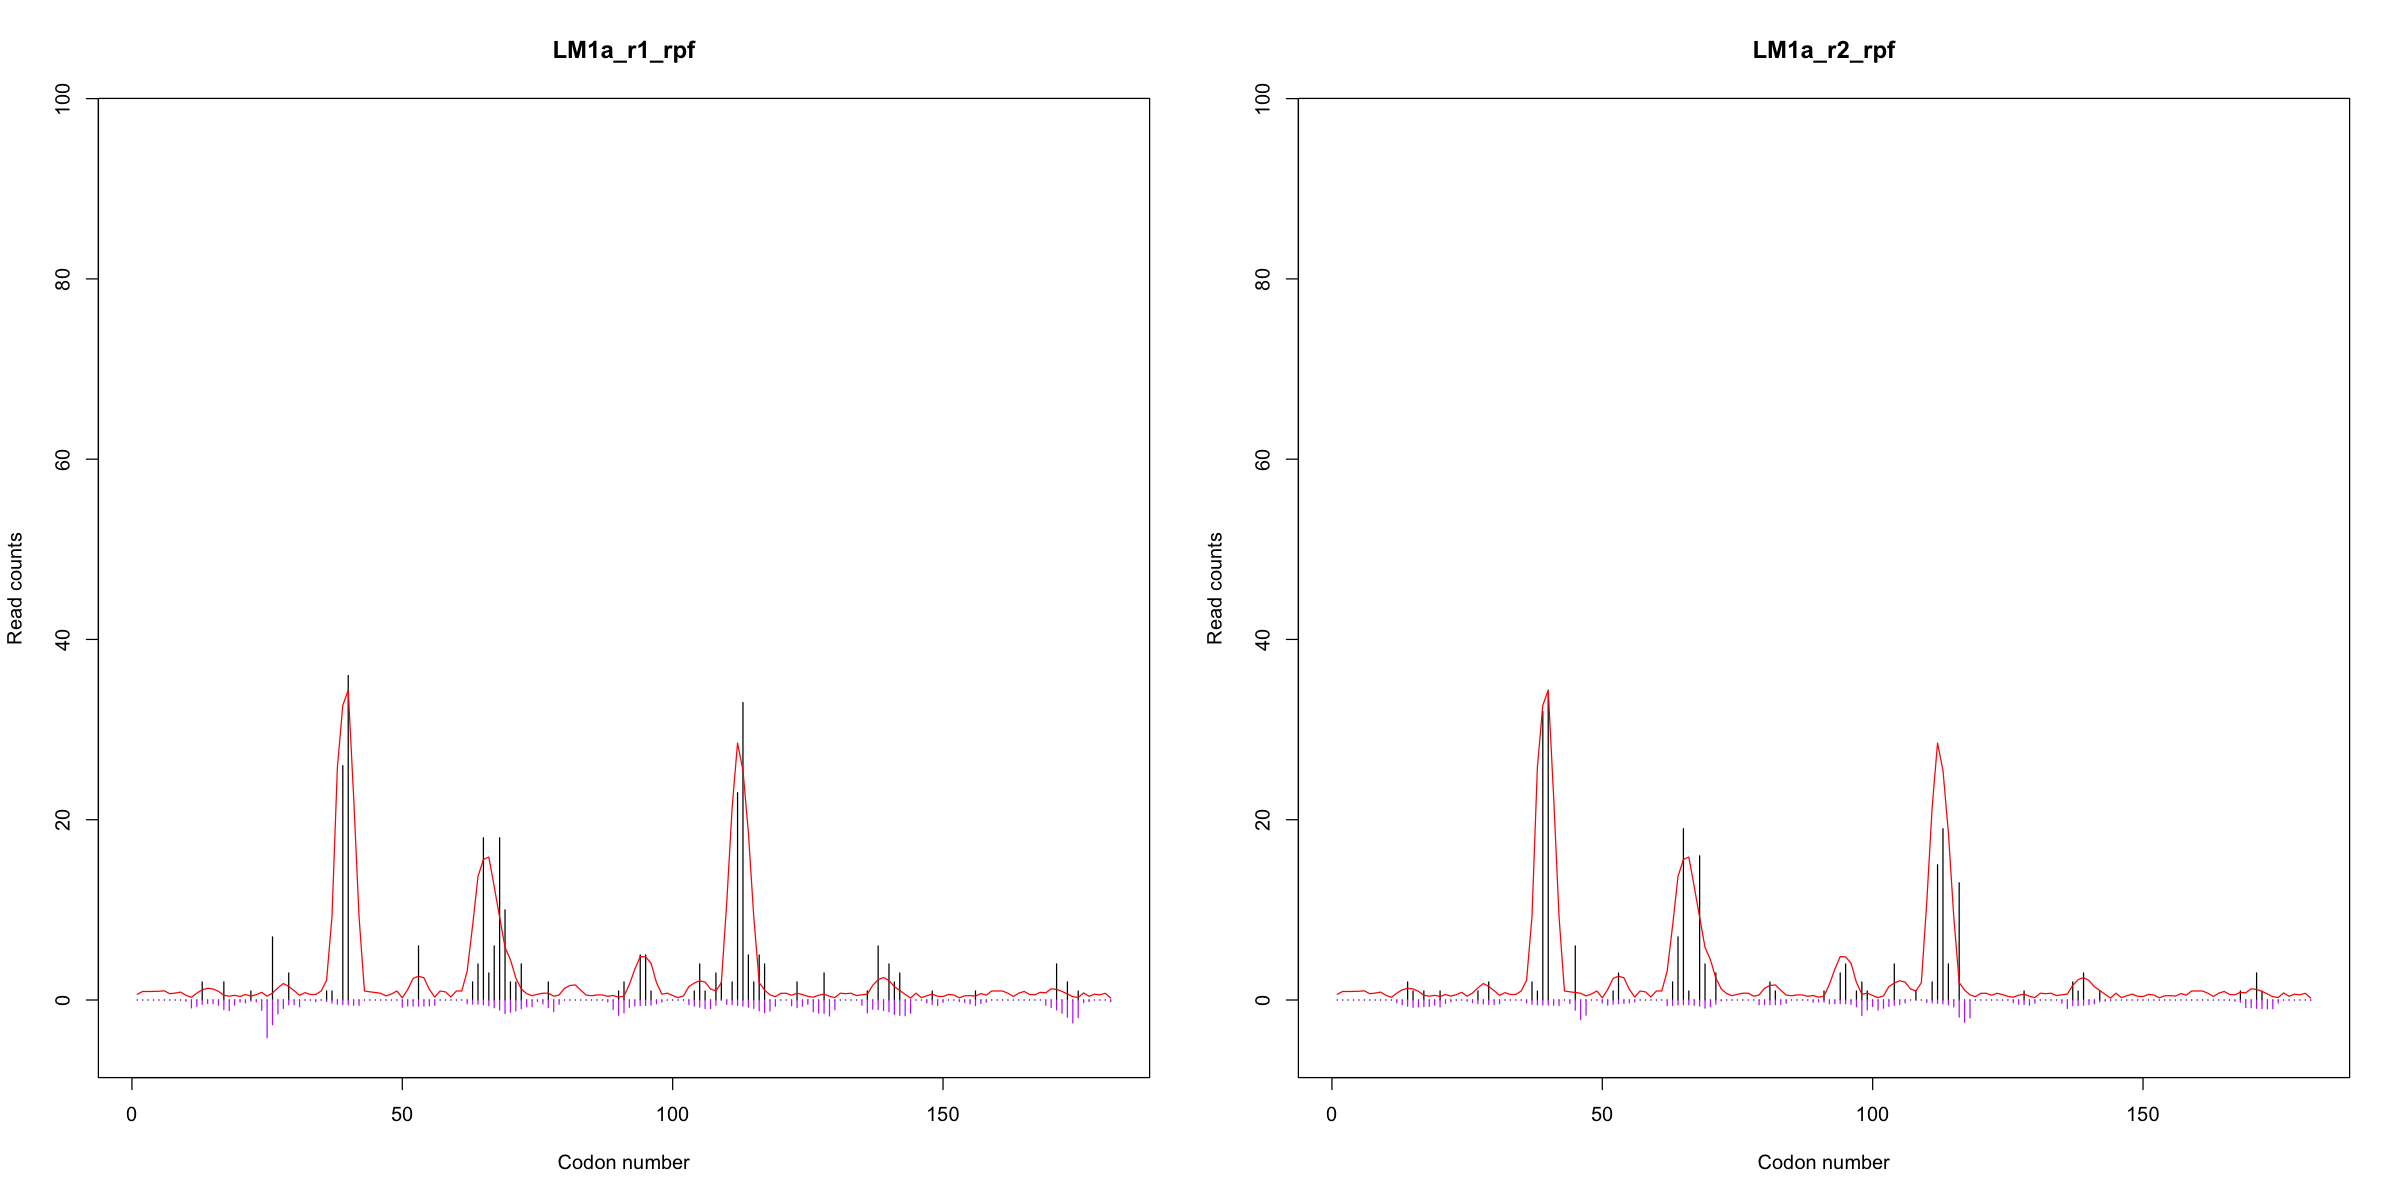

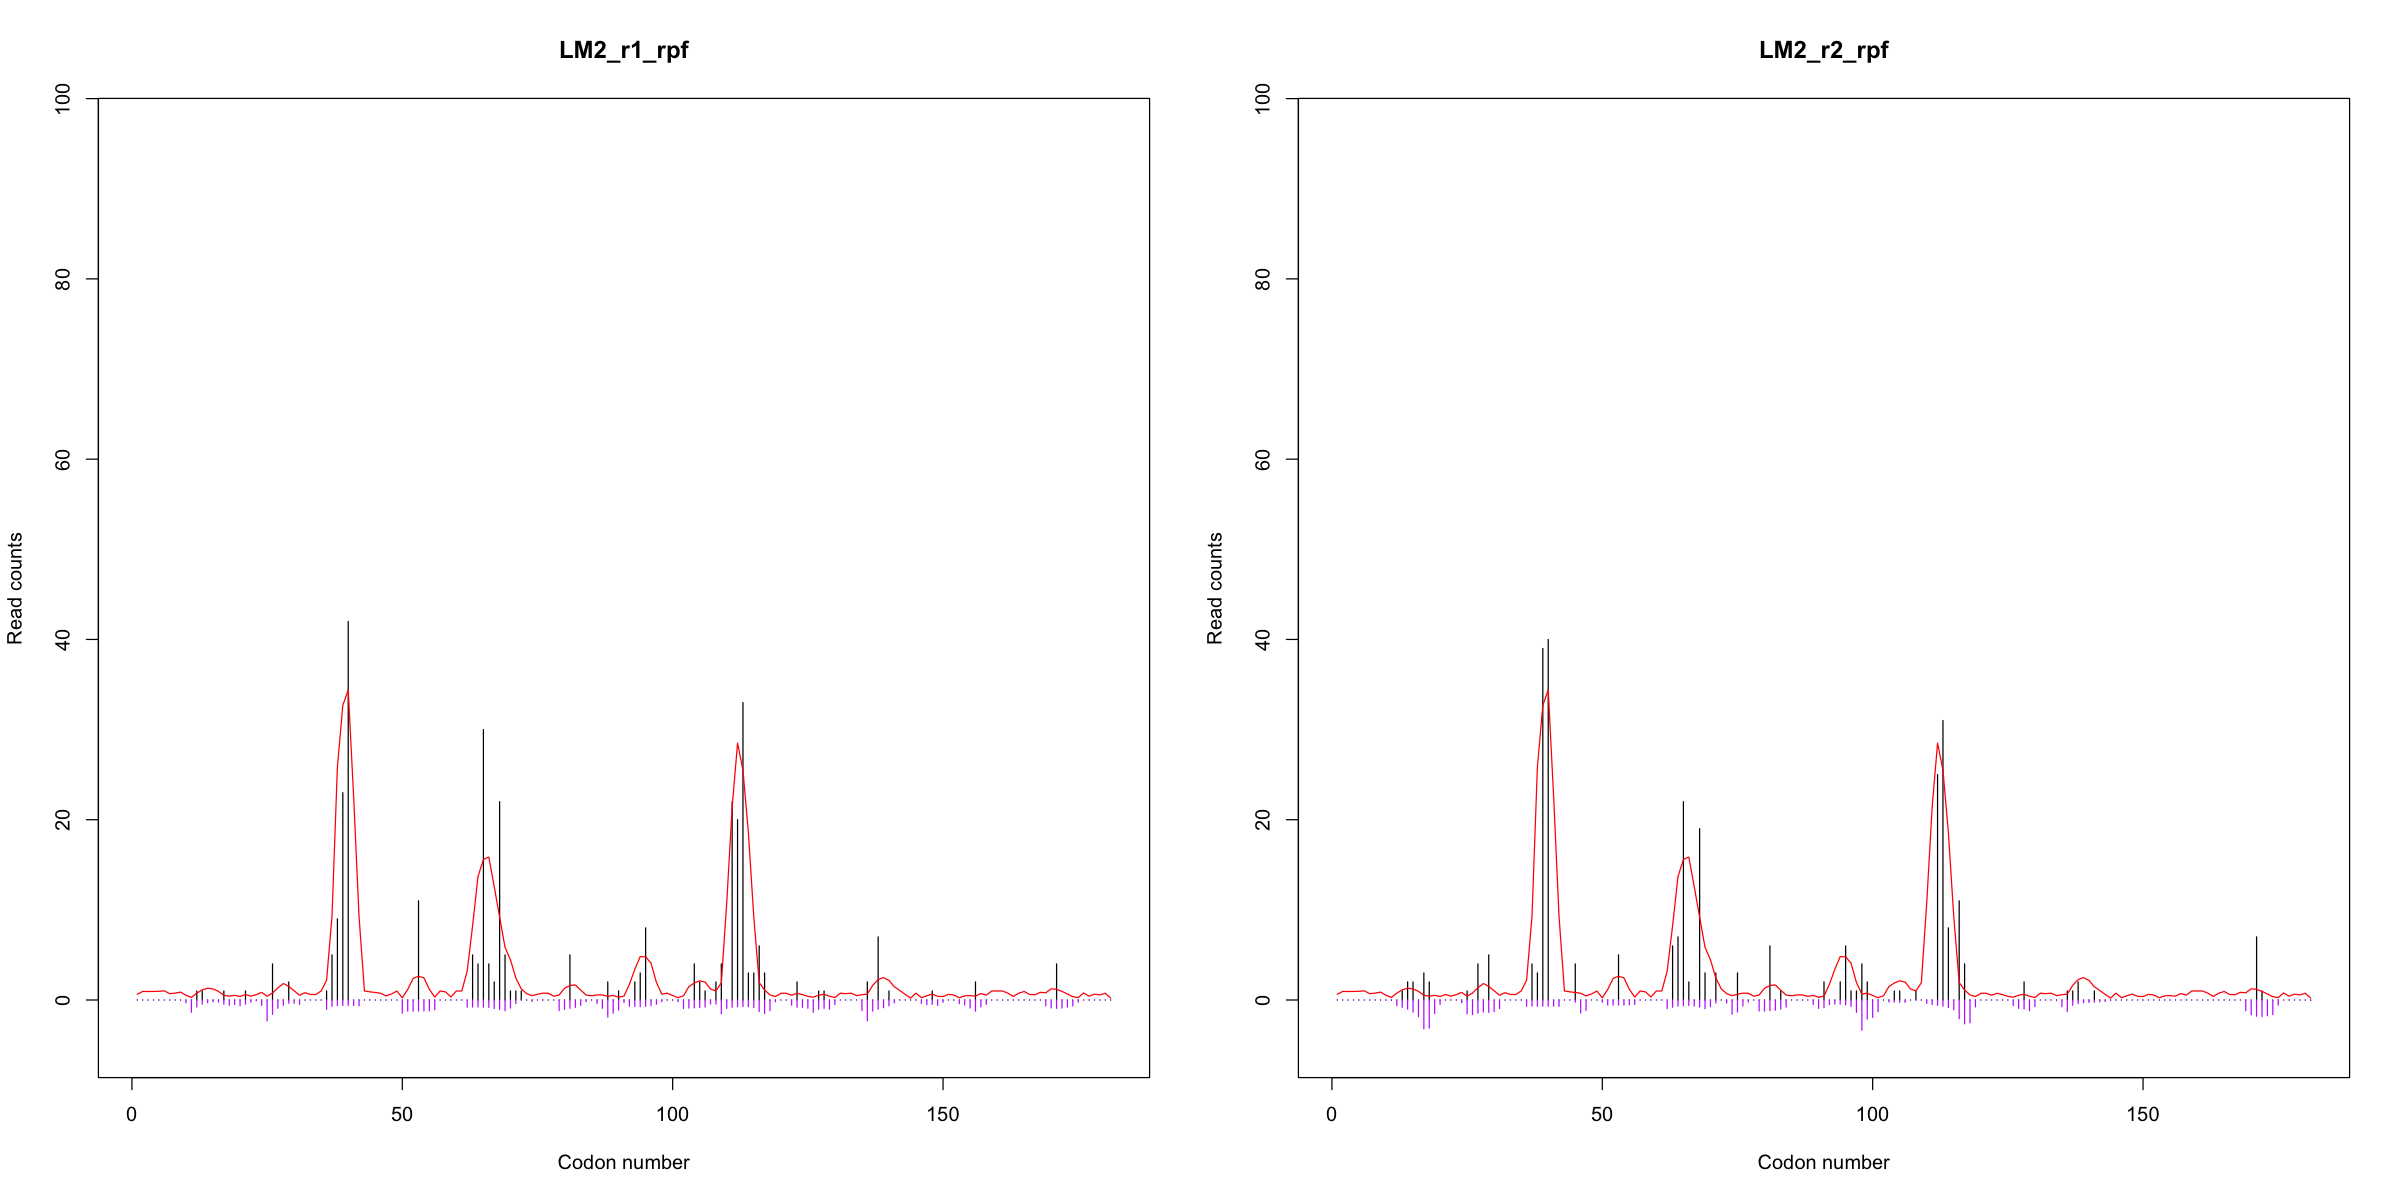

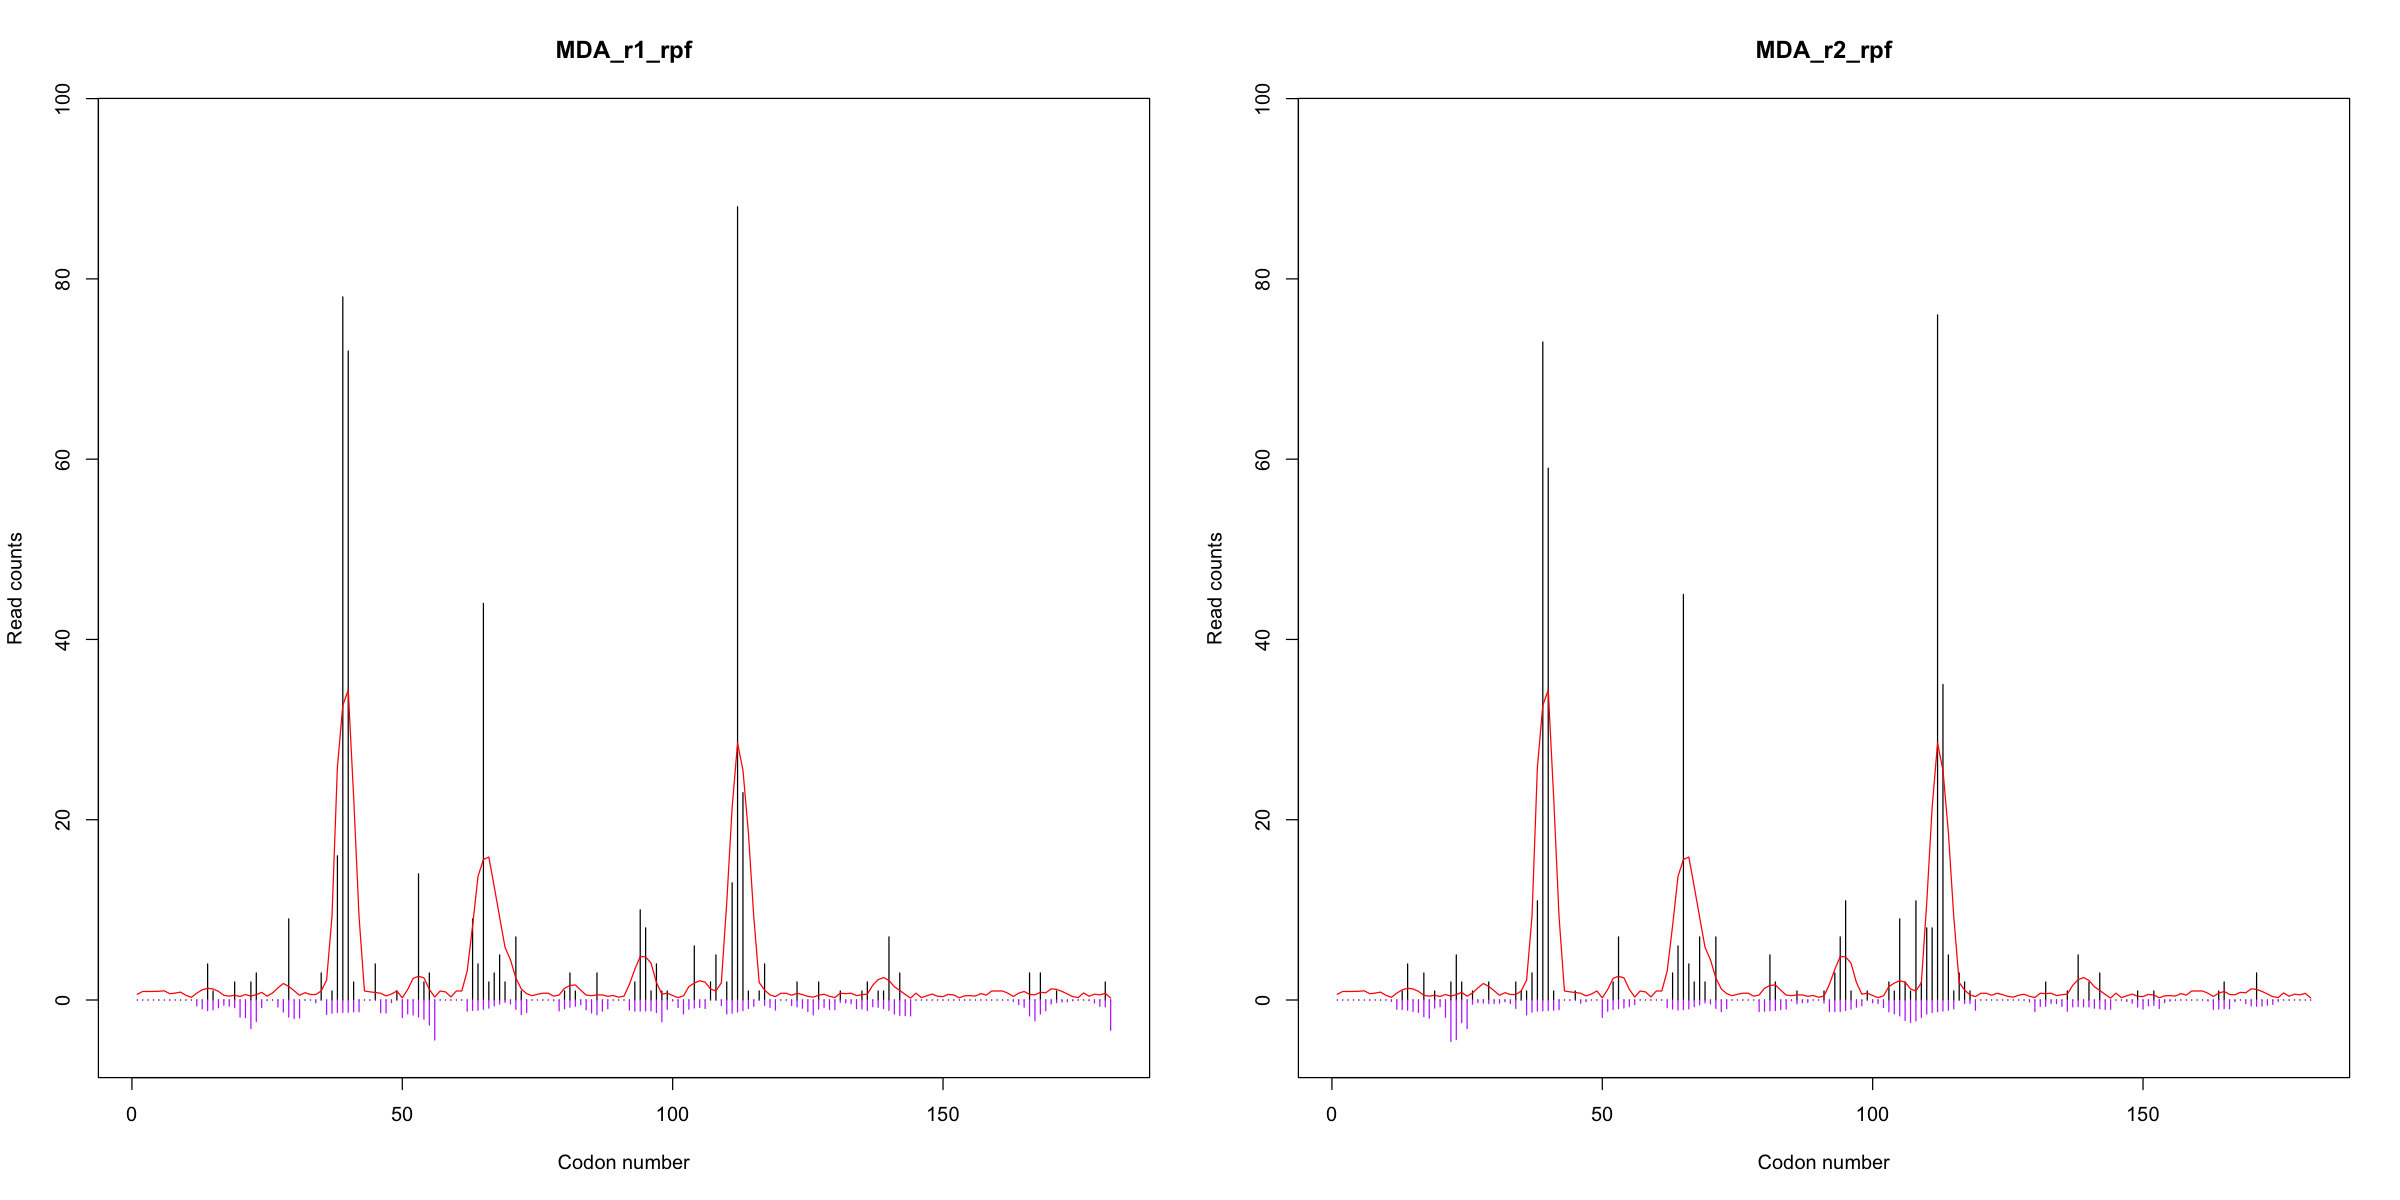

In [23]:
options(repr.plot.width = 20, repr.plot.height = 10)
Ribolog::visualize_CELP(tr_codon_bias_coeff_loess_corrected_count$tr_codon_read_count_loess_corrected, 
                        transcript = "ENST00000000233", panel_rows = 1, panel_cols = 2)

- You can also save these plots to a PDF as below

In [24]:
Ribolog::visualize_CELP(tr_codon_bias_coeff_loess_corrected_count$tr_codon_read_count_loess_corrected, 
                        transcript = "ENST00000000233", panel_rows = 2, panel_cols = 4, 
                        outfile='ENST00000000233.CELP.bias.plots.pdf')

[1] "PDF (ENST00000000233.CELP.bias.plots.pdf) created and saved"

### Generate corrected transcript read counts

- Observed or corrected codon read counts are summed up to produce transcript read counts. The analysis of translational efficiency is usually performed at transcript level.
- The expected execution time for the observed counts is ~5 seconds / bam file.
- The expected execution time for the corrected counts is ~5 seconds / bam file.

In [25]:
rpf_corrected_sum <- Ribolog::codon2transcript(tr_codon_bias_coeff_loess_corrected_count$tr_codon_read_count_loess_corrected
                                               ,count_type = "corrected_count")

Warning message in Ribolog::codon2transcript(tr_codon_bias_coeff_loess_corrected_count$tr_codon_read_count_loess_corrected, :
“There are 4580 transcripts that have 0 counts across all samples. Use Ribolog::min_count_filter to remove them before translational efficiency testing.”


In [26]:
head(rpf_corrected_sum)

,transcript,CN34_r1_rpf,CN34_r2_rpf,LM1a_r1_rpf,LM1a_r2_rpf,LM2_r1_rpf,LM2_r2_rpf,MDA_r1_rpf,MDA_r2_rpf
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,165.31557,154.840107,100.682043,63.334847,93.508422,100.029817,142.287906,124.444429
2,ENST00000000412,140.61610,111.472792,51.202281,43.722382,61.176334,54.901641,110.507570,84.393704
3,ENST00000000442,51.10705,38.477754,23.606509,17.900931,34.819383,26.850651,34.009938,28.119936
4,ENST00000001008,305.40022,311.471853,198.805227,170.710114,203.935828,227.280674,245.101472,217.527673
5,ENST00000001146,12.43855,5.450122,10.223084,8.531586,7.428010,8.512812,5.474177,3.299516
6,ENST00000002125,42.50277,26.873808,2.713572,9.539419,7.952022,15.322697,21.146686,18.955195


## Step 2.2: Create RNA Counts Matrix and merge with RPF counts

- The step below converts specific rna bam files into counts.
- The average run time is ~12 seconds/bam file.

### Create the RNA counts data frame

In [27]:
rna_count <- bam2count(bamfolder='~/Downloads/fastq/rna', annotation = annotation) 

In [28]:
names(rna_count)

[1] "transcript"  "CN34_r1_rna" "CN34_r2_rna" "LM1a_r1_rna" "LM1a_r2_rna"
[6] "LM2_r1_rna"  "LM2_r2_rna"  "MDA_r1_rna"  "MDA_r2_rna"

### Merge the RNA counts with the corrected RPF counts data

In [29]:
rna_CELP_rpf_count <- merge(rna_count, rpf_corrected_sum, by = "transcript") 

In [30]:
head(rna_CELP_rpf_count)

,transcript,CN34_r1_rna,CN34_r2_rna,LM1a_r1_rna,LM1a_r2_rna,LM2_r1_rna,LM2_r2_rna,MDA_r1_rna,MDA_r2_rna,CN34_r1_rpf,CN34_r2_rpf,LM1a_r1_rpf,LM1a_r2_rpf,LM2_r1_rpf,LM2_r2_rpf,MDA_r1_rpf,MDA_r2_rpf
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,397,390,437,701,462,889,845,793,165.31557,154.840107,100.682043,63.334847,93.508422,100.029817,142.287906,124.444429
2,ENST00000000412,1570,1524,2096,3052,2114,4260,2441,2264,140.61610,111.472792,51.202281,43.722382,61.176334,54.901641,110.507570,84.393704
3,ENST00000000442,764,762,799,1251,829,1555,1511,1480,51.10705,38.477754,23.606509,17.900931,34.819383,26.850651,34.009938,28.119936
4,ENST00000001008,1767,1631,2116,3041,2119,4268,2675,2559,305.40022,311.471853,198.805227,170.710114,203.935828,227.280674,245.101472,217.527673
5,ENST00000001146,99,75,75,128,64,150,81,75,12.43855,5.450122,10.223084,8.531586,7.428010,8.512812,5.474177,3.299516
6,ENST00000002125,165,137,174,272,177,379,324,278,42.50277,26.873808,2.713572,9.539419,7.952022,15.322697,21.146686,18.955195


## Step 2.3: Normalize counts for library size variation and remove transcripts with low counts

By default, we use the median-of-ratios method for library size normalization. Users can normalize their data in any other way they prefer outside Ribolog and pass on the result to modules 3 and 4. RNA data and RPF data must be normalized separately. The normalize_median_of_ratios function allows specification of data columns, and thus, indepedent normalization of RPF and RNA columns in a mixed RNA-RPF data set.

- The normalize_median_of_ratios function allows specification of data columns, and thus, indepedent normalization of RPF and RNA columns in a mixed RNA-RPF data set.

### Normalize RNA and RPF counts

In [31]:
rna_CELP_rpf_count_norm1 <- Ribolog::normalize_median_of_ratios(rna_CELP_rpf_count, 
                                                                data_columns = c(2:9) ) # Remember that Column 1 is the transcript name so its not included here
rr <- Ribolog::normalize_median_of_ratios(rna_CELP_rpf_count_norm1, 
                                                                data_columns = c(10:17) )

[1] "Normalization factors:"
CN34_r1_rna CN34_r2_rna LM1a_r1_rna LM1a_r2_rna  LM2_r1_rna  LM2_r2_rna 
  0.7019262   0.6518220   0.9373749   1.3515186   0.8575008   1.7100546 
 MDA_r1_rna  MDA_r2_rna 
  1.2355806   1.2104613 
[1] "Normalization factors:"
CN34_r1_rpf CN34_r2_rpf LM1a_r1_rpf LM1a_r2_rpf  LM2_r1_rpf  LM2_r2_rpf 
  1.6641399   1.5661246   0.7991571   0.7143870   0.8937141   0.9034438 
 MDA_r1_rpf  MDA_r2_rpf 
  1.2473342   1.0325690 


In [32]:
head(rr)

,transcript,CN34_r1_rna,CN34_r2_rna,LM1a_r1_rna,LM1a_r2_rna,LM2_r1_rna,LM2_r2_rna,MDA_r1_rna,MDA_r2_rna,CN34_r1_rpf,CN34_r2_rpf,LM1a_r1_rpf,LM1a_r2_rpf,LM2_r1_rpf,LM2_r2_rpf,MDA_r1_rpf,MDA_r2_rpf
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,565.5865,598.3228,466.19552,518.67581,538.7750,519.8664,683.88900,655.12212,99.339946,98.868320,125.985291,88.65622,104.629011,110.720575,114.073607,120.519244
2,ENST00000000412,2236.7024,2338.0616,2236.03159,2258.20054,2465.3039,2491.1485,1975.58940,1870.36126,84.497761,71.177474,64.070356,61.20266,68.451795,60.769293,88.595001,81.731785
3,ENST00000000442,1088.4335,1169.0308,852.38036,925.62545,966.7630,909.3277,1222.90683,1222.67432,30.710789,24.568770,29.539258,25.05775,38.960316,29.720333,27.266101,27.232986
4,ENST00000001008,2517.3587,2502.2168,2257.36777,2250.06154,2471.1348,2495.8267,2164.97405,2114.06999,183.518357,198.880635,248.768634,238.96029,228.189116,251.571458,196.500249,210.666486
5,ENST00000001146,141.0405,115.0621,80.01067,94.70828,74.6355,87.7165,65.55622,61.95985,7.474464,3.480005,12.792333,11.94253,8.311394,9.422624,4.388701,3.195444
6,ENST00000002125,235.0675,210.1801,185.62476,201.25509,206.4138,221.6303,262.22489,229.66450,25.540383,17.159432,3.395543,13.35329,8.897725,16.960321,16.953505,18.357316


### Filter out low count transcripts

In [33]:
rr.v1 <- Ribolog::min_count_filter(rr, mincount = 5, columns = c(2:9), method = "all") # Remove transcripts with low RPF counts

In [34]:
rr.v2 <- Ribolog::min_count_filter(rr.v1, mincount = 2, columns = c(10:17), method = "average") # Remove transcripts with low RNA counts

In [35]:
head(rr.v2)

,transcript,CN34_r1_rna,CN34_r2_rna,LM1a_r1_rna,LM1a_r2_rna,LM2_r1_rna,LM2_r2_rna,MDA_r1_rna,MDA_r2_rna,CN34_r1_rpf,CN34_r2_rpf,LM1a_r1_rpf,LM1a_r2_rpf,LM2_r1_rpf,LM2_r2_rpf,MDA_r1_rpf,MDA_r2_rpf
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,565.5865,598.3228,466.19552,518.67581,538.7750,519.8664,683.88900,655.12212,99.339946,98.868320,125.985291,88.65622,104.629011,110.720575,114.073607,120.519244
2,ENST00000000412,2236.7024,2338.0616,2236.03159,2258.20054,2465.3039,2491.1485,1975.58940,1870.36126,84.497761,71.177474,64.070356,61.20266,68.451795,60.769293,88.595001,81.731785
3,ENST00000000442,1088.4335,1169.0308,852.38036,925.62545,966.7630,909.3277,1222.90683,1222.67432,30.710789,24.568770,29.539258,25.05775,38.960316,29.720333,27.266101,27.232986
4,ENST00000001008,2517.3587,2502.2168,2257.36777,2250.06154,2471.1348,2495.8267,2164.97405,2114.06999,183.518357,198.880635,248.768634,238.96029,228.189116,251.571458,196.500249,210.666486
5,ENST00000001146,141.0405,115.0621,80.01067,94.70828,74.6355,87.7165,65.55622,61.95985,7.474464,3.480005,12.792333,11.94253,8.311394,9.422624,4.388701,3.195444
6,ENST00000002125,235.0675,210.1801,185.62476,201.25509,206.4138,221.6303,262.22489,229.66450,25.540383,17.159432,3.395543,13.35329,8.897725,16.960321,16.953505,18.357316


### Save progress since this final counts matrix will be the main input for Module 3 and Module 4

In [36]:
saveRDS(rr.v2, 'final_counts.RDS')

In [37]:
rr.v2 <- readRDS('final_counts.RDS')

## Step 2.4 (Optional): Codon Stalling / Ribosome Dwell Time Analysis

- These functions detect per-codon and per-amino-acid ribosome stalling (dwell time) differences between levels of any covariate you want to test.
- get_codon_bias_coefficients splits tr_codon_read_count by a covariate from your sample attributes table, runs CELP_detect_bias separately within each level, and combines the bias coefficients into one data frame.
- get_codon_dwell_time_estimates / get_aa_dwell_time_estimates then fit a per-codon or per-amino-acid model comparing the covariate's levels, and plot_codon_dwell_times / plot_aa_dwell_times visualize the results.

- Set these to whatever covariate in your own sample_attributes you want to compare (e.g. genotype, treatment, condition), and its reference/baseline level. This is not tied to any particular study - any two-level column in your design table can be used.

In [38]:
covariate_name <- "lung_metastasis"  # e.g. "genotype", "treatment"
ref_level <- "N"        # the baseline level of covariate_name

- The function below is time consuming (>= 10 minutes)

In [39]:
codon_bias_df <- get_codon_bias_coefficients(tr_codon_read_count, sample_attributes, 
                           sample_ID = "sample_name", covariate_name = covariate_name)

In [40]:
head(codon_bias_df)

,transcript,codon_number,codon_type,aa_type,bias_coefficient,lung_metastasis
,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>
1,ENST00000003084,1,ATG,M,1,N
2,ENST00000003084,2,CAG,Q,1,N
3,ENST00000003084,3,AGG,R,1,N
4,ENST00000003084,4,TCG,S,1,N
5,ENST00000003084,5,CCT,P,1,N
6,ENST00000003084,6,CTG,L,1,N


### Per-codon dwell time estimates

- The function below takes time (5-10 mins)

In [41]:
codon_dwell_time_ests <- get_codon_dwell_time_estimates(codon_bias_df, covariate_name = covariate_name, ref_level = ref_level)

In [42]:
head(codon_dwell_time_ests)

,codon,mean_dwell_time,p_val
,<chr>,<dbl>,<dbl>
1,GCG,0.062783732,8.284951e-06
2,ATG,0.042021618,5.129500e-04
3,CCC,0.007263816,3.225152e-04
4,GCC,0.001675386,4.962281e-01
5,CCG,-0.001165953,8.237034e-01
6,CTC,-0.004724960,5.389013e-02


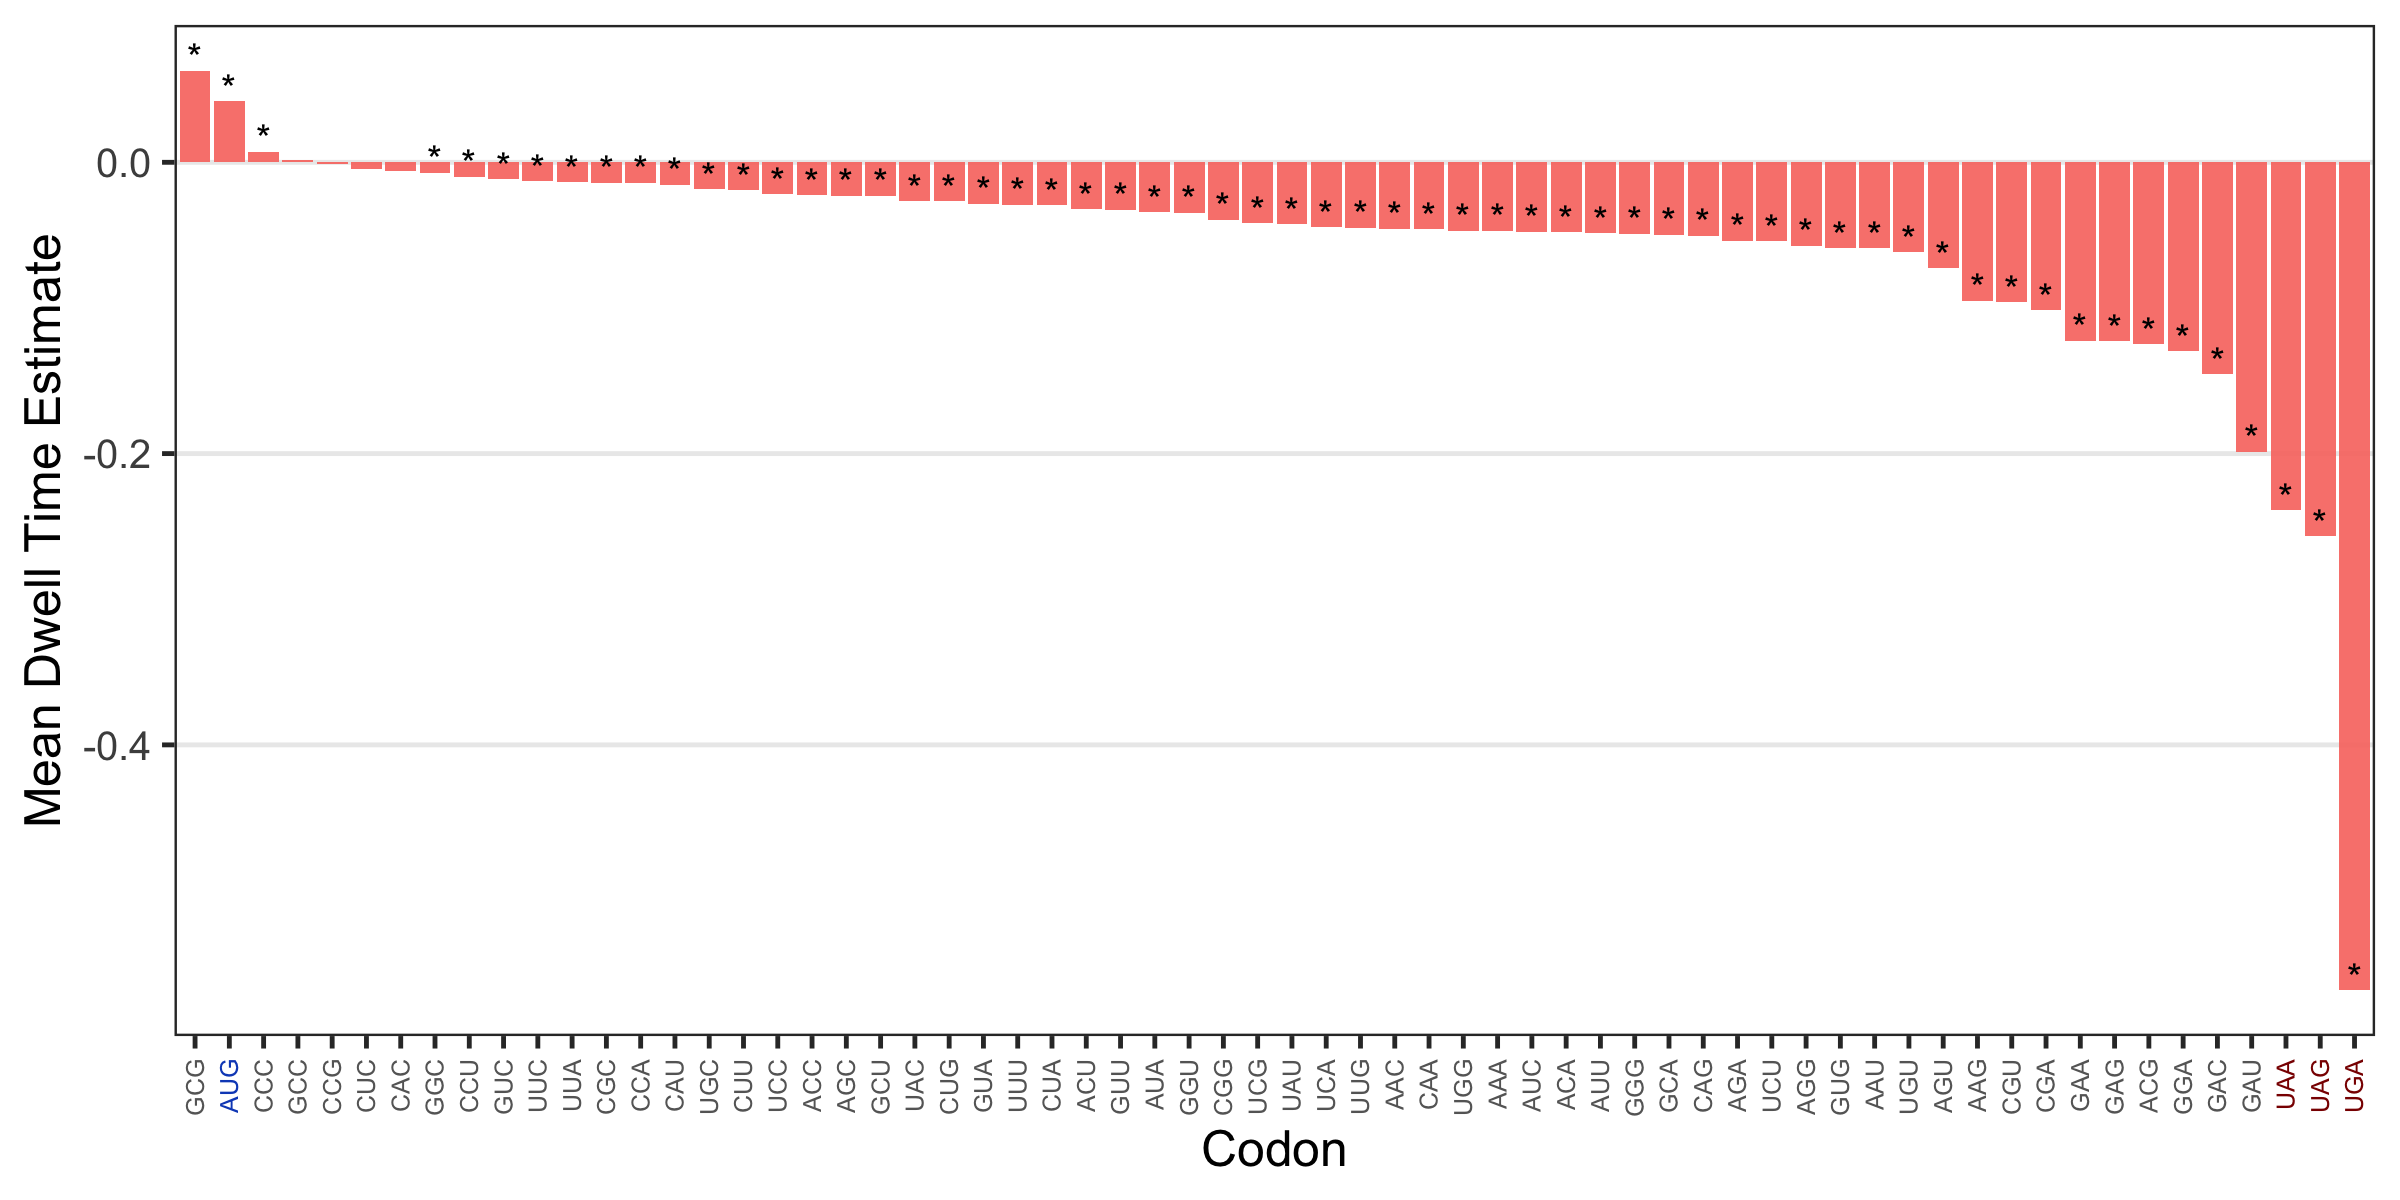

In [43]:
options(repr.plot.width = 20, repr.plot.height = 10)
plot_codon_dwell_times(codon_dwell_time_ests)

### Per-amino-acid dwell time estimates

- The function below takes a little bit of time (2-5 mins)

In [44]:
aa_dwell_time_ests <- get_aa_dwell_time_estimates(codon_bias_df, covariate_name = covariate_name, ref_level = ref_level)

In [45]:
head(aa_dwell_time_ests)

,amino_acid,mean_dwell_time,p_val
,<chr>,<dbl>,<dbl>
1,Methionine,0.042021618,5.129500e-04
2,Proline,-0.004555999,3.552272e-03
3,Histidine,-0.009874833,1.933144e-05
4,Alanine,-0.009938380,1.383808e-04
5,Phenylalanine,-0.020512904,1.882907e-15
6,Leucine,-0.023130759,2.062721e-56


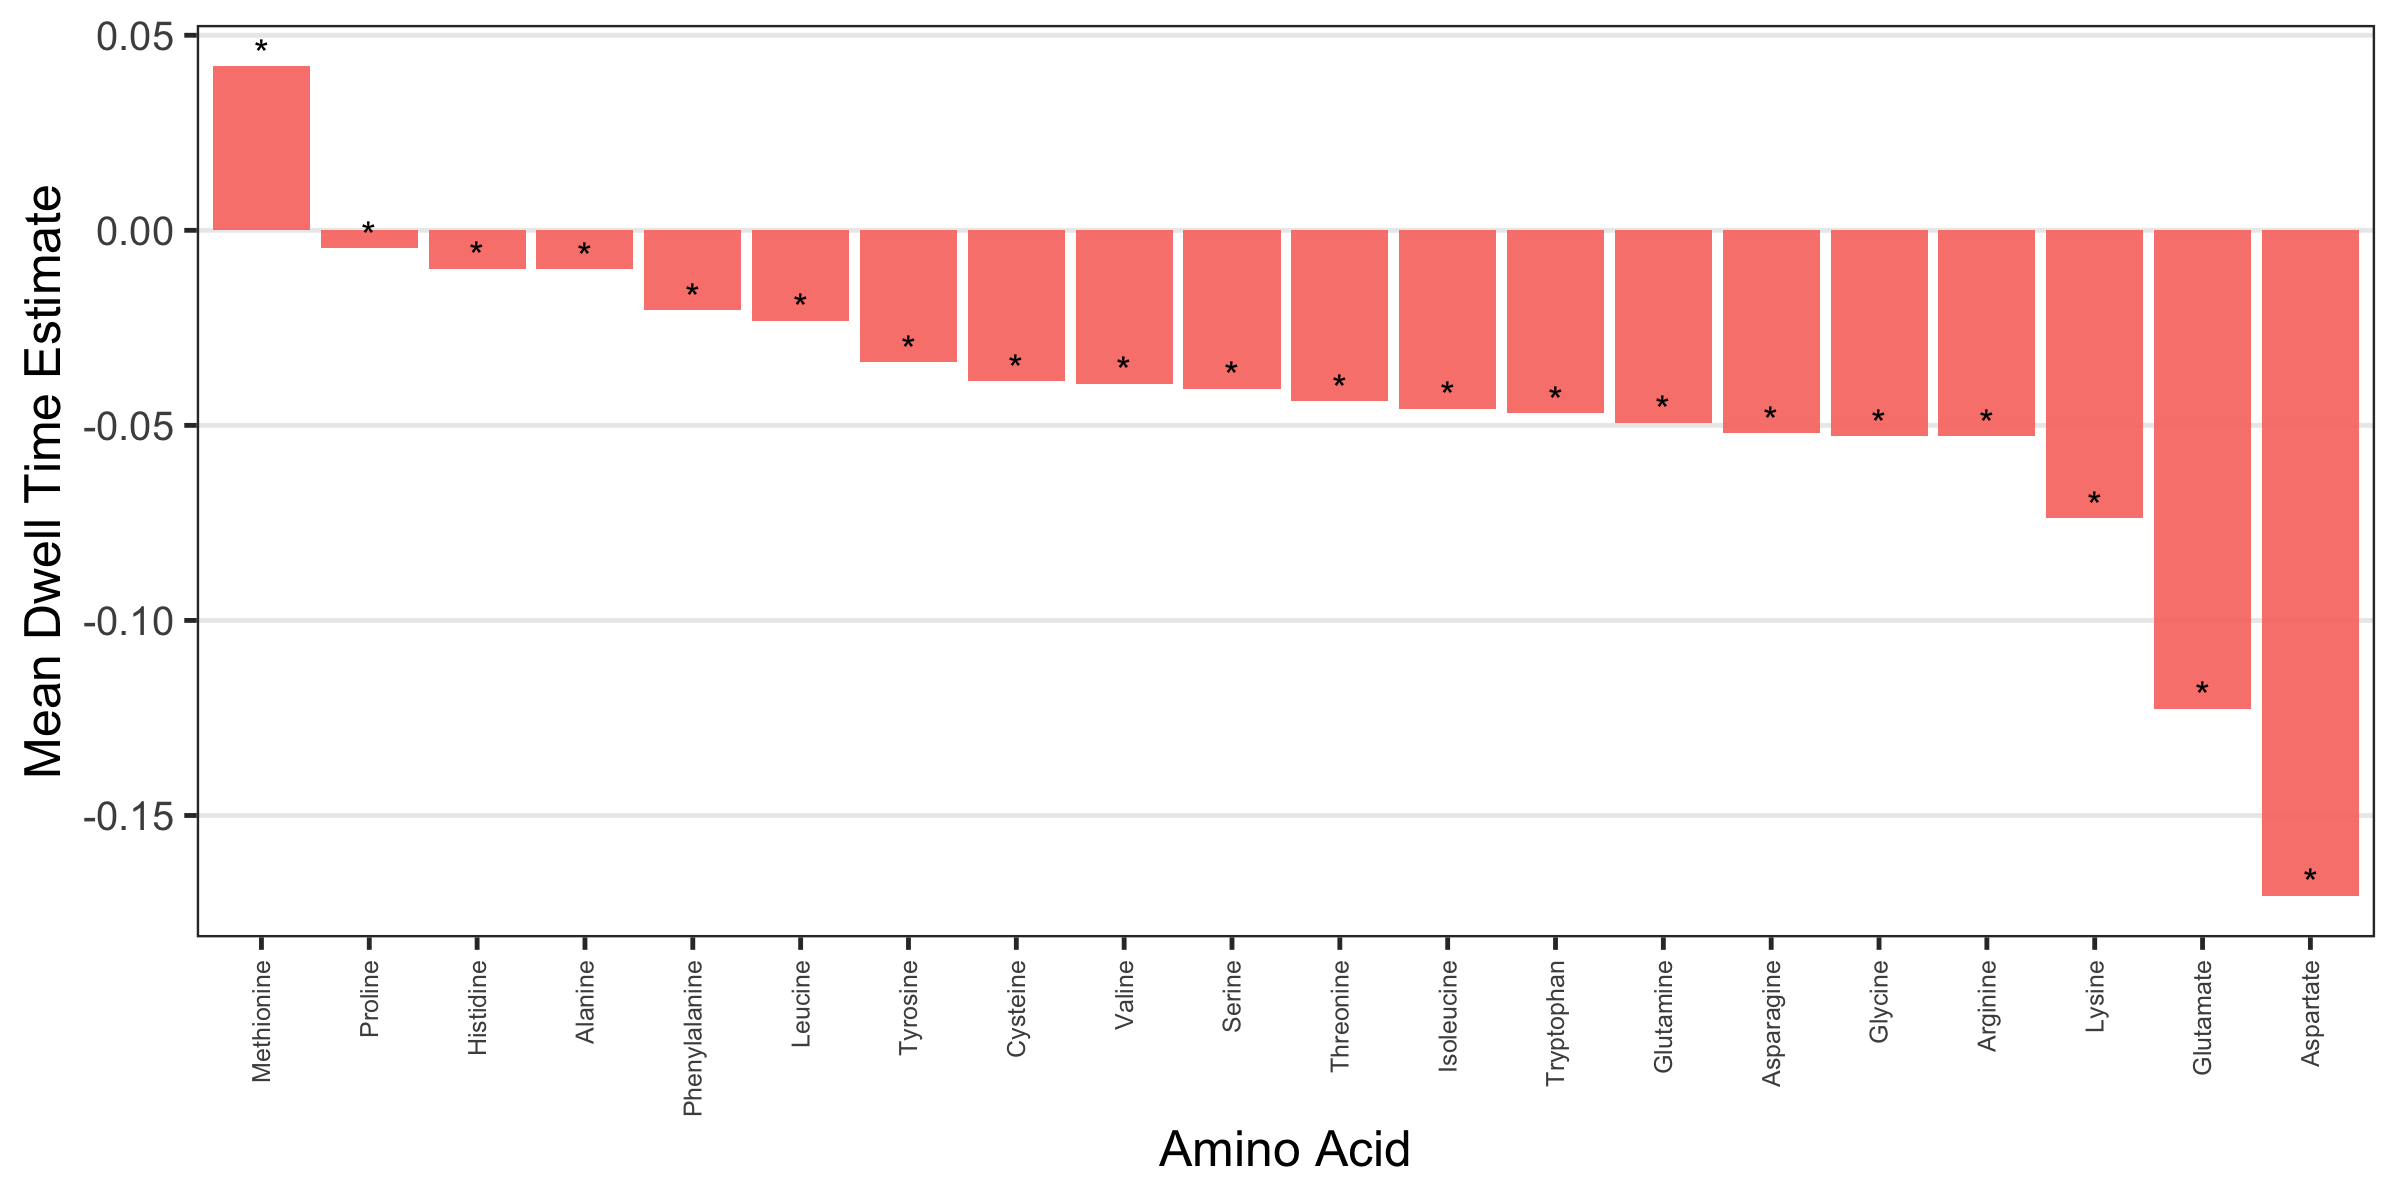

In [46]:
options(repr.plot.width = 20, repr.plot.height = 10)
Ribolog::plot_aa_dwell_times(aa_dwell_time_ests)

# Module 3: QC of Transcript-level Data

The QC module includes functions to check the quality of ribosome profiling data focusing mainly on the reproducibility of translational efficiency (TE) among replicates. Tools for general QC of sequencing data (e.g. FASTQC) or 3-base periodicity of ribo-seq libraries (borrowed from the riboWaltz package and covered in module 1) are not repeated here.

A minimum read count cutoff is usually applied to sequencing data to remove extremely low count features which would yield unreliable results. To demonstrate, we filter our dataset to keep only transcripts with RNA>=5 in all samples and average RPF>=2 across samples. This can be done using the min_count_filter function. You can choose methods between “all” or “average” and apply different cutoffs until you find a value setting that produces acceptable output in terms of replicate consistency.

## Step 3.1: Standardize the data

- PCA is a statistical procedure that decomposes the total variance in data to several orthogonal (not linearly correlated) components. The variance in a transcript x sample matrix of read counts originates not only from differences among samples, but also from differences of (mean) counts across transcripts (there is also an interaction term but we will not deal with that just now). The output of PCA is sensitive to the scale of input numbers. If PCA is performed on the raw RNA counts, the pattern will be driven disproportionately by highly expressed genes. The same is true about RPF counts or TE values and highly translated transcripts. It is therefore customary in some applications to center or standardize the data before performing the PCA. Centering the data means subtracting the row mean or column mean from each element. Standardization means dividing the centered data by the corresponding row or column standard deviation. The choice of row- or column- standardization depends on the data type and structure, and the aim of the study. We perform PCA to visualize similarities and distances among samples. Row centering will bring the mean count for each transcript to zero which means that the differences in the average read counts of transctipts will not be incorporated into the total variance. Row standardization accomplishes the same goal but also guranatees that each transcript adds exactly one unit of variance to the variance of the transcript x sample matrix. Thus, all transctipts contribute equally to the PCA pattern.

- First, we need to create a TE data set by dividing RPF columns by their RNA counterparts from the same sample. This is done using the create-te function:

In [47]:
te.v2 <- Ribolog::create_te(rr.v2, idcolumns = 1, rnacolumns = c(2:9), rpfcolumns = c(10:17))

In [48]:
head(te.v2)

,transcript,CN34_r1_te,CN34_r2_te,LM1a_r1_te,LM1a_r2_te,LM2_r1_te,LM2_r2_te,MDA_r1_te,MDA_r2_te
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENST00000000233,0.17564058,0.16524243,0.27024132,0.17092800,0.19419796,0.21297889,0.16680135,0.18396455
2,ENST00000000412,0.03777783,0.03044294,0.02865360,0.02710240,0.02776607,0.02439409,0.04484485,0.04369840
3,ENST00000000442,0.02821559,0.02101636,0.03465502,0.02707116,0.04029976,0.03268385,0.02229614,0.02227330
4,ENST00000001008,0.07290116,0.07948177,0.11020297,0.10620167,0.09234183,0.10079685,0.09076333,0.09964972
5,ENST00000001146,0.05299517,0.03024459,0.15988283,0.12609803,0.11135979,0.10742135,0.06694561,0.05157281
6,ENST00000002125,0.10865130,0.08164157,0.01829251,0.06635009,0.04310625,0.07652527,0.06465254,0.07993101


In [49]:
te.v2.cent <- Ribolog::row_center(te.v2, columns = c(2:9)) 
te.v2.stnd <- Ribolog::row_standardize(te.v2, columns = c(2:9))

## Step 3.2: Creating the PCA Plots

Only the numerical part of the data set is fed into the pca_qc function which means that the ID column(s) must be manually excluded. The argument n specifies the number of PCs to be plotted.

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     0.2281 0.1251 0.06040 0.05179 0.04099 0.03806 0.03382
Proportion of Variance 0.6565 0.1974 0.04602 0.03383 0.02119 0.01827 0.01443
Cumulative Proportion  0.6565 0.8540 0.90001 0.93384 0.95503 0.97331 0.98773
                           PC8
Standard deviation     0.03118
Proportion of Variance 0.01227
Cumulative Proportion  1.00000


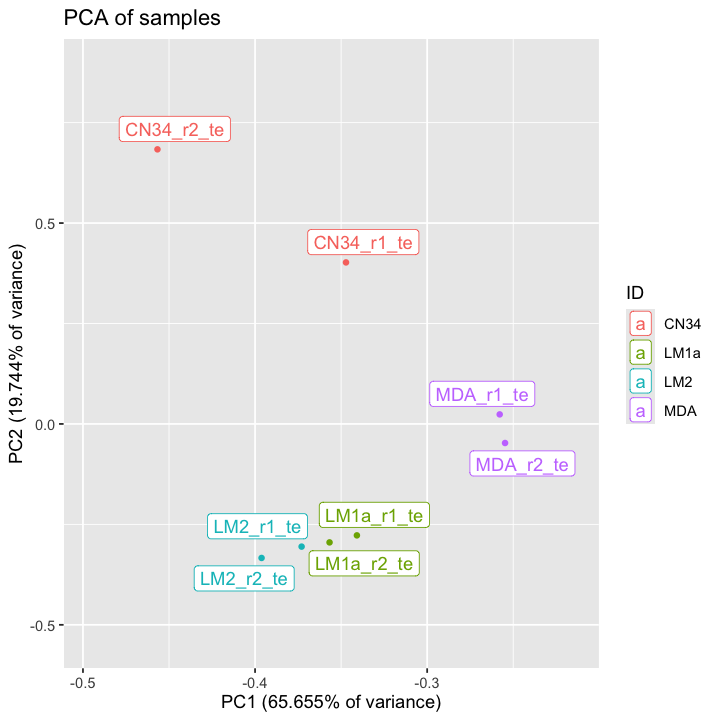

In [50]:
options(repr.plot.width = 6, repr.plot.height = 6)
pca_qc(te.v2[, -1], n = 2, ID = sample_attributes$cell_line[c(1:8)])

### PCA with Low count transcripts filtered out, data row-centered.

Importance of components:
                          PC1     PC2     PC3     PC4     PC5     PC6     PC7
Standard deviation     0.1256 0.07001 0.05189 0.04200 0.03868 0.03382 0.03119
Proportion of Variance 0.5486 0.17058 0.09371 0.06137 0.05207 0.03980 0.03385
Cumulative Proportion  0.5486 0.71920 0.81290 0.87427 0.92635 0.96615 1.00000
                             PC8
Standard deviation     1.621e-16
Proportion of Variance 0.000e+00
Cumulative Proportion  1.000e+00


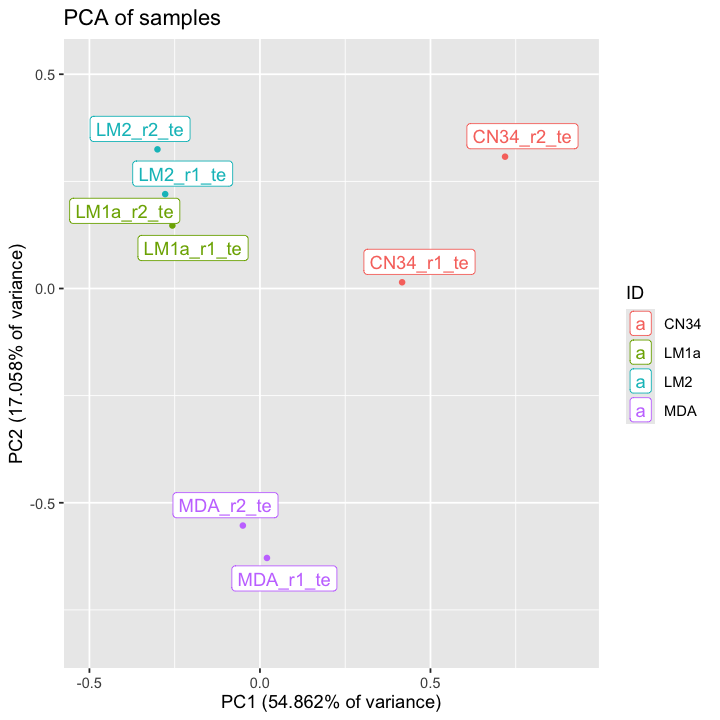

In [51]:
pca_qc(te.v2.cent[, -1], n = 2, ID = sample_attributes$cell_line[c(1:8)])

### PCA with Low count transcripts filtered out, data row-standardized

Importance of components:
                          PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     1.4458 1.1622 1.0538 0.8418 0.81367 0.75777 0.66607
Proportion of Variance 0.3012 0.1946 0.1600 0.1021 0.09539 0.08274 0.06393
Cumulative Proportion  0.3012 0.4958 0.6558 0.7579 0.85334 0.93607 1.00000
                         PC8
Standard deviation     3e-15
Proportion of Variance 0e+00
Cumulative Proportion  1e+00


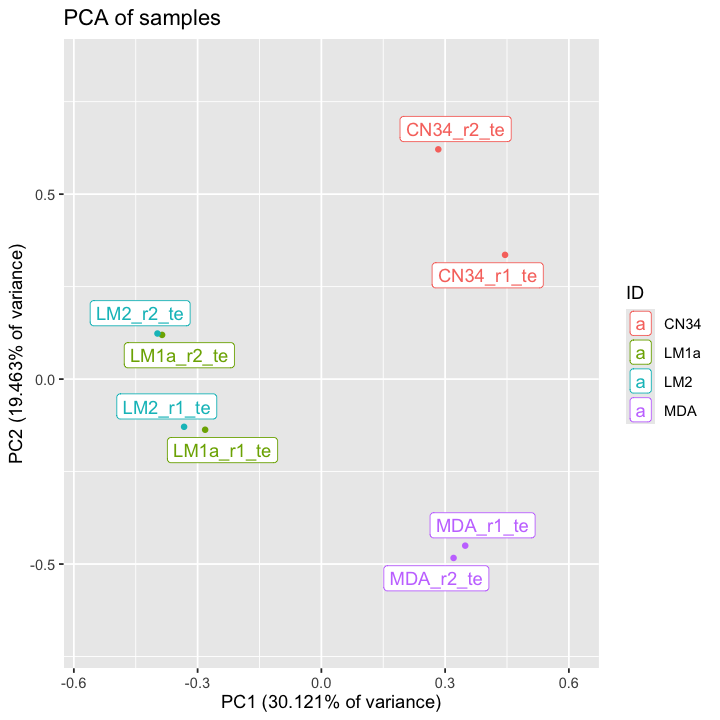

In [52]:
pca_qc(te.v2.stnd[, -1], n = 2, ID = sample_attributes$cell_line[c(1:8)])

## Step 3.3: Repeat PCA plots on RNA and RPF counts separately for further QC

To further investigate why TE of the LM1a and LM2 reps seem somewhat mismacthed, we repeat the PCA on RNA and RPF data:

In [53]:
# Standardize RNA counts 
rr.v3 <- row_standardize(rr.v2, columns = c(2:9)) 
# Standardize RPF counts 
rr.v4 <- row_standardize(rr.v3, columns = c(10:17))

### PCA on RNA counts

Importance of components:
                          PC1    PC2     PC3     PC4     PC5     PC6    PC7
Standard deviation     1.7604 1.4807 0.78277 0.52492 0.48387 0.38953 0.3623
Proportion of Variance 0.4628 0.3274 0.09149 0.04115 0.03496 0.02266 0.0196
Cumulative Proportion  0.4628 0.7901 0.88164 0.92278 0.95774 0.98040 1.0000
                             PC8
Standard deviation     1.954e-15
Proportion of Variance 0.000e+00
Cumulative Proportion  1.000e+00


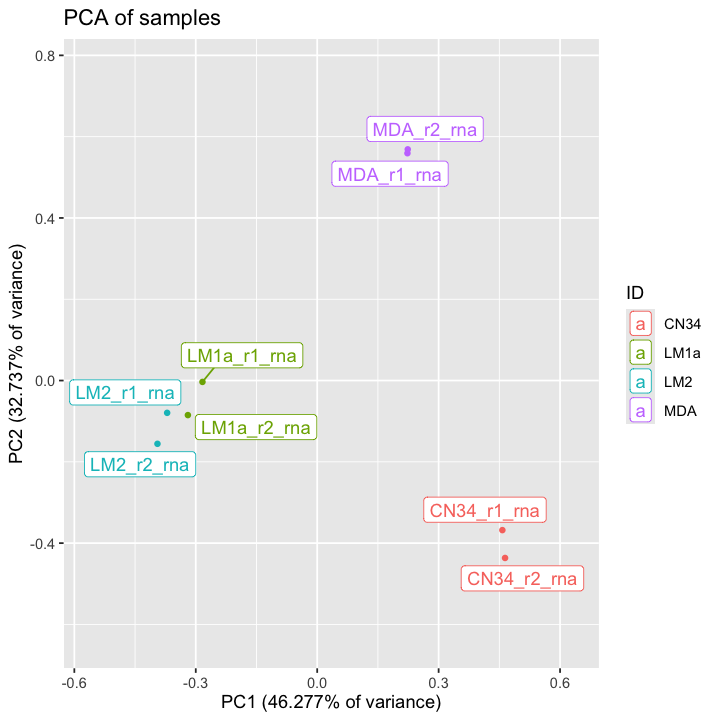

In [54]:
# PCA on RNA counts 
Ribolog::pca_qc(rr.v4[, c(2:9)], n = 2, ID = sample_attributes$cell_line[c(1:8)])

### PCA on RPF Counts

Importance of components:
                          PC1    PC2    PC3    PC4     PC5    PC6     PC7
Standard deviation     1.5947 1.0993 0.9566 0.8597 0.79328 0.7727 0.60592
Proportion of Variance 0.3633 0.1727 0.1308 0.1056 0.08991 0.0853 0.05245
Cumulative Proportion  0.3633 0.5360 0.6667 0.7723 0.86224 0.9476 1.00000
                             PC8
Standard deviation     2.248e-15
Proportion of Variance 0.000e+00
Cumulative Proportion  1.000e+00


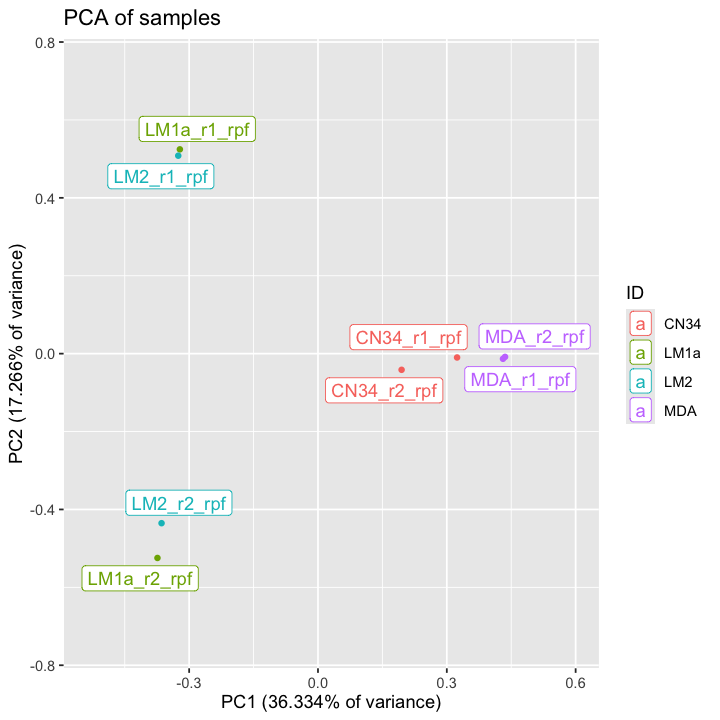

In [55]:
# PCA on RPF counts
Ribolog::pca_qc(rr.v4[, c(10:17)], n = 2, ID = sample_attributes$cell_line[c(9:16)])

PC1 separates the metastatic from non-metastatic lines in both RNA and RPF plots. Replicate consistency seems better for RNA compared to RPF which could be due to the larger RNA read counts in general. The mismatch between reps of the two metastatic cell lines appears to originate from their RPF counts.
The above analyses inform our next step (translational efficiency significance testing): There is a clear difference between metatstatic and non-metastatic lines, but the distinction within these groups is not as large or reliable. Therefore, the most biologically relevant analysis would be to compare TE between metastatic and non-metastatic groups.

# Module 4: Basic differential translational efficiency test

Now we are ready to perform the translational efficiency test using the logit_seq function. TE is the RPF/RNA ratio. If we are interested in comparing TE between the metastatic and non-metastatic samples, we set the model to read_type ~ lung_metastasis. The count data set (argument x) must contain only numeric variables, therefore column 1 (transcript) is excluded from x and provided separately as the feature list in the end.

Regression reports usually include only a regression coefficient (Estimate) and a p-value. We keep SE and z in the output data frame to enable certain tasks e.g. generation of correlograms from z scores (module 3, TEST 3).

Finally, p-values are corrected for multiple testing. Run ?logit_seq to see all the available methods. Two examples are shown below. Each column of p-values is corrected for multiple testing separately.

## Step 4.1: Perform Logit test on the TE estimates

In [56]:
# id_mapper maps transcript IDs -> gene IDs/names (bundled with the package)
mapper <- Ribolog::human_id_mapper

In [57]:
head(mapper)

,transcript,gene_id,gene_name
,<fct>,<fct>,<fct>
1,ENST00000003084,ENSG00000001626,CFTR
2,ENST00000001146,ENSG00000003137,CYP26B1
3,ENST00000002125,ENSG00000003509,NDUFAF7
4,ENST00000000233,ENSG00000004059,ARF5
5,ENST00000002829,ENSG00000001617,SEMA3F
6,ENST00000001008,ENSG00000004478,FKBP4


In [58]:
ter_testing_results <-    logit_seq(rr.v2[, -1],
                                    sample_attributes,
                                    read_type ~ lung_metastasis,
                                    as.vector(rr.v2$transcript),
                                    adj_method = 'fdr',
                                    id_mapper = mapper,
                                    id_column = 'gene_name') 

In [59]:
head(ter_testing_results)

,logFC_intercept,std_intercept,zvalue_intercept,pvalue_intercept,corrected_pvalue_intercept,logFC_lung_metastasisY,std_lung_metastasisY,zvalue_lung_metastasisY,pvalue_lung_metastasisY,corrected_pvalue_lung_metastasisY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARF5,-1.754935,0.05205781,-33.71128,3.951134e-249,8.064794e-249,0.1962742,0.07433026,2.640569,8.276697e-03,0.0263197597
M6PR,-3.251546,0.05644508,-57.60549,0.000000e+00,0.000000e+00,-0.3630183,0.08497169,-4.272227,1.935304e-05,0.0001463526
ESRRA,-3.757499,0.09653616,-38.92323,0.000000e+00,0.000000e+00,0.3683345,0.13305698,2.768247,5.635878e-03,0.0192051346
FKBP4,-2.466138,0.03706833,-66.52951,0.000000e+00,0.000000e+00,0.1844950,0.05013194,3.680188,2.330618e-04,0.0012813455
CYP26B1,-3.029793,0.23774767,-12.74373,3.378306e-37,3.739031e-37,0.9582711,0.28816076,3.325474,8.826836e-04,0.0040019339
NDUFAF7,-2.485984,0.11783821,-21.09659,8.548524e-99,1.147908e-98,-0.4650948,0.19642640,-2.367782,1.789509e-02,0.0495716173


You can also simply extract uncorrected values by specifying 'none' as the adjustment method

An important advantage of Ribolog is that it can run the TER test using only a single replicate per sample, or a single sample per biological condition. Below, we compare CN34 and LM1a lines using only one replicate from each:

## Step 4.2: Make Volcano Plots

We can visualize the results in volcano plots

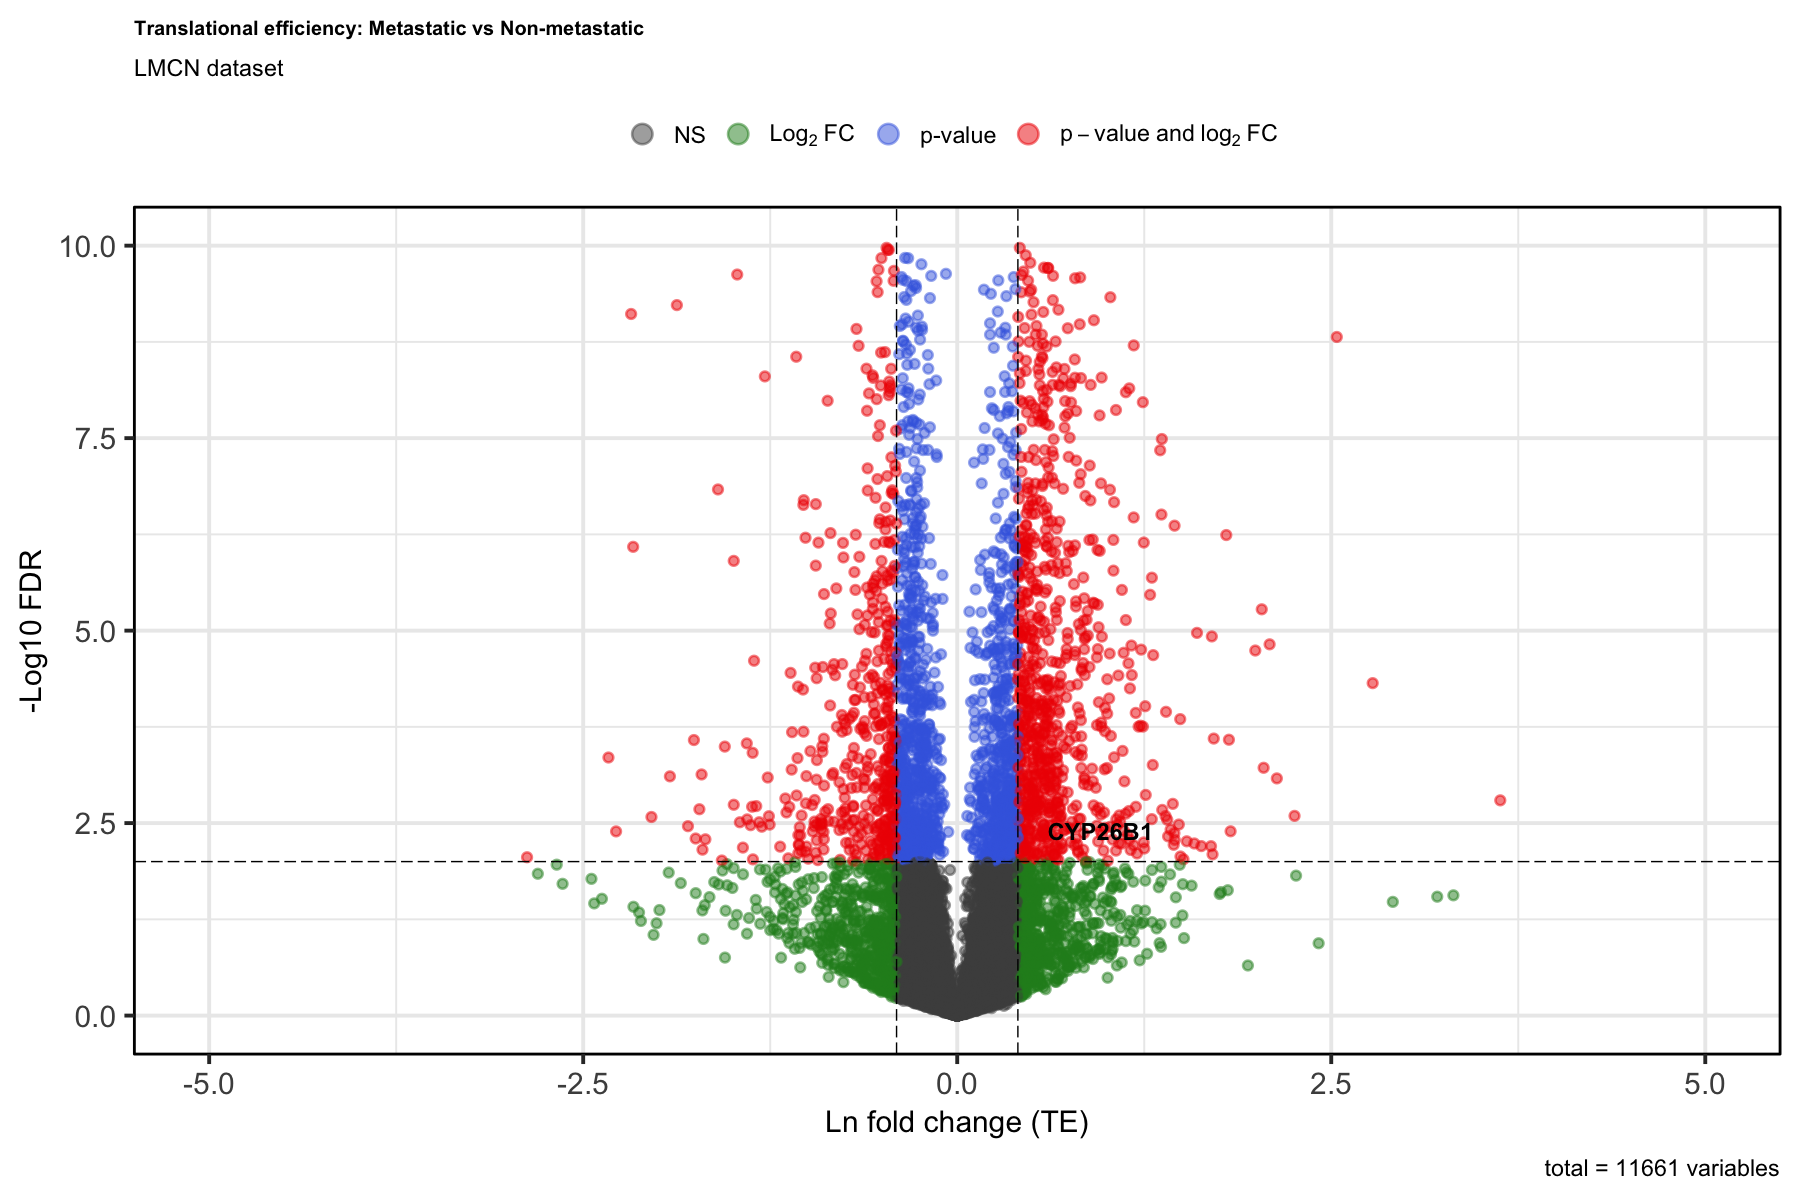

In [60]:
options(repr.plot.width = 15, repr.plot.height = 10)
volcano_plot(ter_testing_results,
             covariate = "lung_metastasis",     # matches the logFC_lung_metastasisY / corrected_pvalue_lung_metastasisY columns
             title = "Translational efficiency: Metastatic vs Non-metastatic",
             subtitle = "LMCN dataset",
             xlab = "Ln fold change (TE)",
             ylab = "-Log10 FDR",
             pCutoff = 0.01,
             FCcutoff = 1.5,
             selectLab = c("CYP26B1"))    

## Module 5: Empirical Null Testing and Meta-analysis

- Standard TER test p-values assume the z statistic follows a theoretical standard normal null. In large-scale data this assumption can be wrong (batch effects, mapping noise, overdispersion), which can make theoretical p-values too small. This module offers two alternative tools: **empirical null (EN) testing**, which derives the null distribution directly from replicate-vs-replicate comparisons in your own data, and **meta-analysis**, which combines correlated test results (e.g. from separate datasets, or rep-by-rep sub-tests) into one consensus.

## Step 5.1: Empirical Null Testing

- build_empirical_null splits the data into unique replicate preparations and compares every pair of replicates of the same biological sample (no real difference expected) to build up the empirical null distribution of z statistics.
- Set uniqueID to whatever column in sample_attributes uniquely identifies each RNA/RPF replicate pair (e.g. a replicate name), and groupID to the column defining which replicates belong to the same biological sample.

In [61]:
head(sample_attributes) # Our sample attributes from before

,sample_name,read_type,lung_metastasis,cell_line,replicate_no,replicate_name,cell_line_origin
,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>
1,CN34_r1_rna,RNA,N,CN34,1,CN34_r1,CN34
2,CN34_r2_rna,RNA,N,CN34,2,CN34_r2,CN34
3,LM1a_r1_rna,RNA,Y,LM1a,1,LM1a_r1,CN34
4,LM1a_r2_rna,RNA,Y,LM1a,2,LM1a_r2,CN34
5,LM2_r1_rna,RNA,Y,LM2,1,LM2_r1,MDA
6,LM2_r2_rna,RNA,Y,LM2,2,LM2_r2,MDA


In [62]:
uniqueID <- "replicate_name"  # e.g. a replicate name column, uniquely IDs each RNA/RPF pair

In [63]:
rr_v2_enz <- build_empirical_null(rr.v2[, -1], 
                                  sample_attributes, 
                                  uniqueID = uniqueID, 
                                  groupID = "cell_line")

While running the comparison for read_type ~ replicate_name, 6 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 26 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 29 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 15 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.


- We can visualize the empirical null and check its fit to a normal distribution.

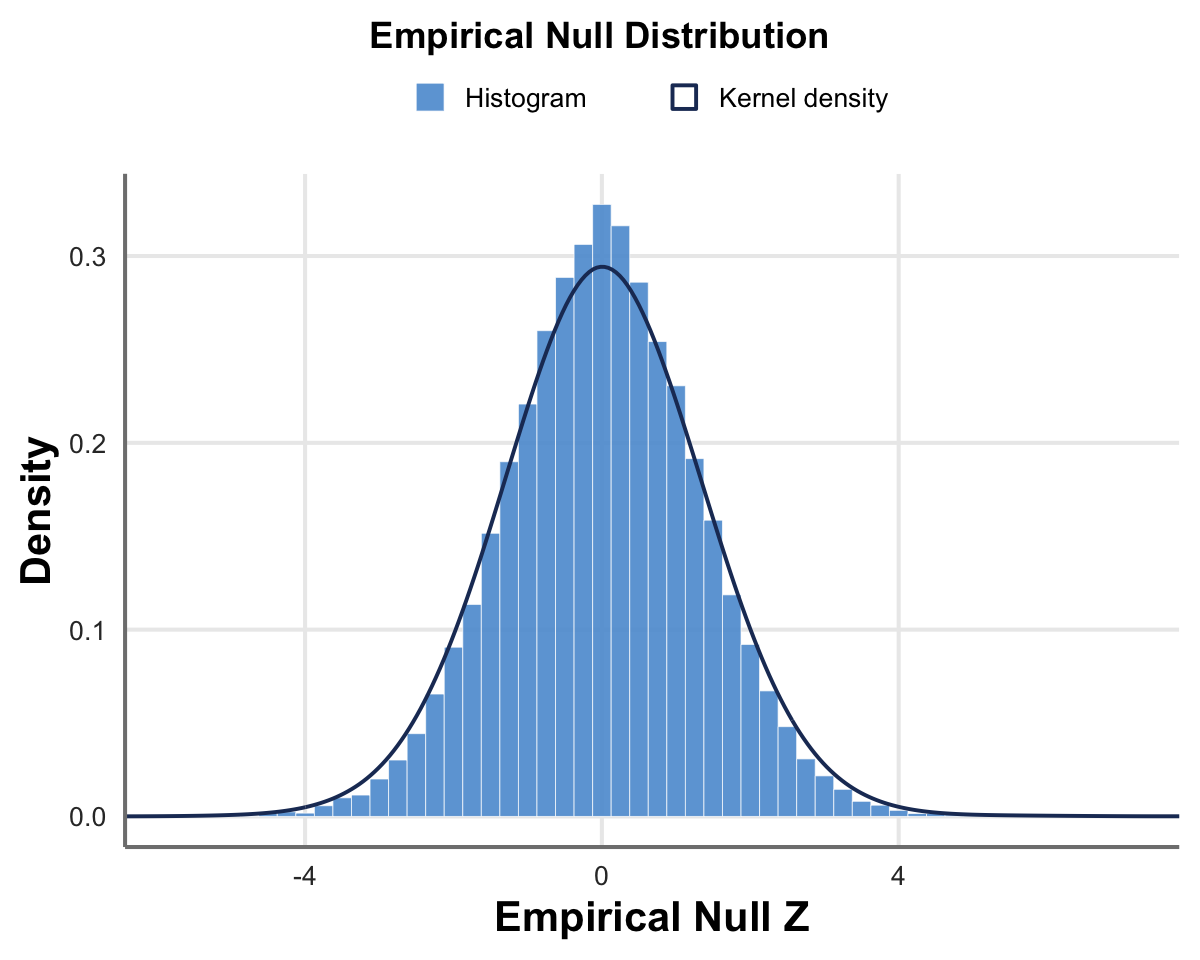

In [64]:
options(repr.plot.width = 10, repr.plot.height = 8)
visualise_empirical_null(rr_v2_enz, 
                        title = "Empirical Null Distribution",
                        subtitle = NULL,
                        xlab = 'Empirical Null Z',
                        ylab = 'Density',
                        axis_text_size = 16, 
                        axis_title_size = 25)

In [65]:
fit_empirical_null(rr_v2_enz, "norm")

Fitting of the distribution ' norm ' by maximum likelihood 
Parameters:
       estimate  Std. Error
mean 0.02027179 0.006532578
sd   1.31519145 0.004619218

## Step 5.2: Perform hypothesis testing using the empirical null

- We need our TER testing results from Module 4

In [66]:
head(ter_testing_results)

,logFC_intercept,std_intercept,zvalue_intercept,pvalue_intercept,corrected_pvalue_intercept,logFC_lung_metastasisY,std_lung_metastasisY,zvalue_lung_metastasisY,pvalue_lung_metastasisY,corrected_pvalue_lung_metastasisY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARF5,-1.754935,0.05205781,-33.71128,3.951134e-249,8.064794e-249,0.1962742,0.07433026,2.640569,8.276697e-03,0.0263197597
M6PR,-3.251546,0.05644508,-57.60549,0.000000e+00,0.000000e+00,-0.3630183,0.08497169,-4.272227,1.935304e-05,0.0001463526
ESRRA,-3.757499,0.09653616,-38.92323,0.000000e+00,0.000000e+00,0.3683345,0.13305698,2.768247,5.635878e-03,0.0192051346
FKBP4,-2.466138,0.03706833,-66.52951,0.000000e+00,0.000000e+00,0.1844950,0.05013194,3.680188,2.330618e-04,0.0012813455
CYP26B1,-3.029793,0.23774767,-12.74373,3.378306e-37,3.739031e-37,0.9582711,0.28816076,3.325474,8.826836e-04,0.0040019339
NDUFAF7,-2.485984,0.11783821,-21.09659,8.548524e-99,1.147908e-98,-0.4650948,0.19642640,-2.367782,1.789509e-02,0.0495716173


In [67]:
# Column 8 is the z statistic for the lung_metastasis term (columns 1-5 = intercept, 6-10 = lung_metastasisY)
ter_testing_ENZ_p <- test_ENZ(x = ter_testing_results, enz = rr_v2_enz, zcols = 8)

In [68]:
head(ter_testing_ENZ_p)

,logFC_intercept,std_intercept,zvalue_intercept,pvalue_intercept,corrected_pvalue_intercept,logFC_lung_metastasisY,std_lung_metastasisY,zvalue_lung_metastasisY,pvalue_lung_metastasisY,corrected_pvalue_lung_metastasisY,ep_lung_metastasisY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ARF5,-1.754935,0.05205781,-33.71128,3.951134e-249,8.064794e-249,0.1962742,0.07433026,2.640569,8.276697e-03,0.0263197597,0.046334720
M6PR,-3.251546,0.05644508,-57.60549,0.000000e+00,0.000000e+00,-0.3630183,0.08497169,-4.272227,1.935304e-05,0.0001463526,0.001099355
ESRRA,-3.757499,0.09653616,-38.92323,0.000000e+00,0.000000e+00,0.3683345,0.13305698,2.768247,5.635878e-03,0.0192051346,0.036670781
FKBP4,-2.466138,0.03706833,-66.52951,0.000000e+00,0.000000e+00,0.1844950,0.05013194,3.680188,2.330618e-04,0.0012813455,0.005389180
CYP26B1,-3.029793,0.23774767,-12.74373,3.378306e-37,3.739031e-37,0.9582711,0.28816076,3.325474,8.826836e-04,0.0040019339,0.011967683
NDUFAF7,-2.485984,0.11783821,-21.09659,8.548524e-99,1.147908e-98,-0.4650948,0.19642640,-2.367782,1.789509e-02,0.0495716173,0.069409366


- Comparing theoretical and empirical p-values (check colnames(ter_testing_ENZ_p) if the column names below don't match exactly):

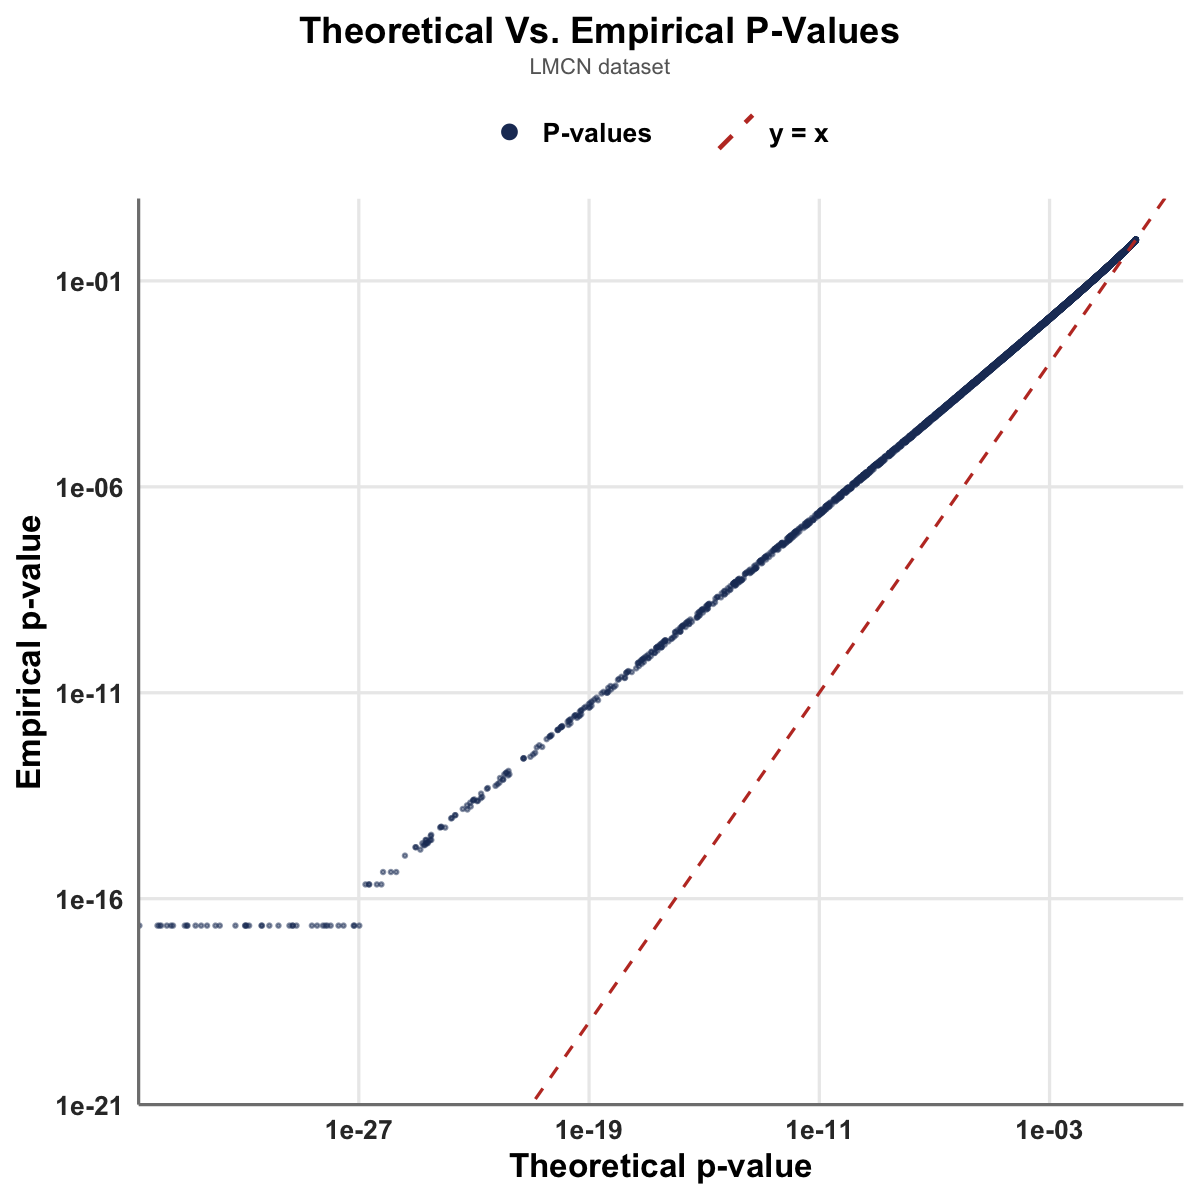

In [69]:
options(repr.plot.width = 10, repr.plot.height = 10)
visualize_pvalue_comparison(ter_testing_ENZ_p, covariate = "lung_metastasis",
                                      title = "Theoretical Vs. Empirical P-Values", subtitle = "LMCN dataset",
                                      xlab = "Theoretical p-value", ylab = "Empirical p-value",
                                      xlim = c(1e-33, 1), ylim = c(1e-20, 1),
                                      axis_title_size = 20, axis_text_size = 16,
                                      legend_text_size = 16)

## Step 5.3: Meta-analysis: combining correlated test results

- meta_test combines results of correlated (non-independent) tests, e.g. the same contrast tested on separate datasets, or several equivalent rep-by-rep sub-tests, into one consensus effect size and p-value (Makambi, K. 2003. *Journal of Applied Statistics*, 30(2): 225-234).

### 5.3.1 Same biological question, separate datasets

- validate_meta_test splits the data by split_var into independent sub-datasets, tests each one separately, combines them with meta_test, and compares the result to a single pooled test - the "gold standard" this alternative approach is meant to approximate.
- Set split_var to whatever column in sample_attributes groups your samples into the independent sub-datasets you'd otherwise have to test separately (e.g. if two labs/protocols each contributed part of the data).

In [70]:
split_var <- "cell_line_origin"  # e.g. a column grouping samples into independent sub-datasets to compare

In [71]:
validation <- Ribolog::validate_meta_test(rr.v2[, -1], sample_attributes,
                                           model = read_type ~ lung_metastasis,
                                           split_var = split_var,
                                           term_name = "lung_metastasisY",
                                           feature_list = as.vector(rr.v2$transcript),
                                           cor_type = "spearman")

          CN34       MDA
CN34 1.0000000 0.4410183
MDA  0.4410183 1.0000000


- Correlograms of the effect size and p-value comparisons:

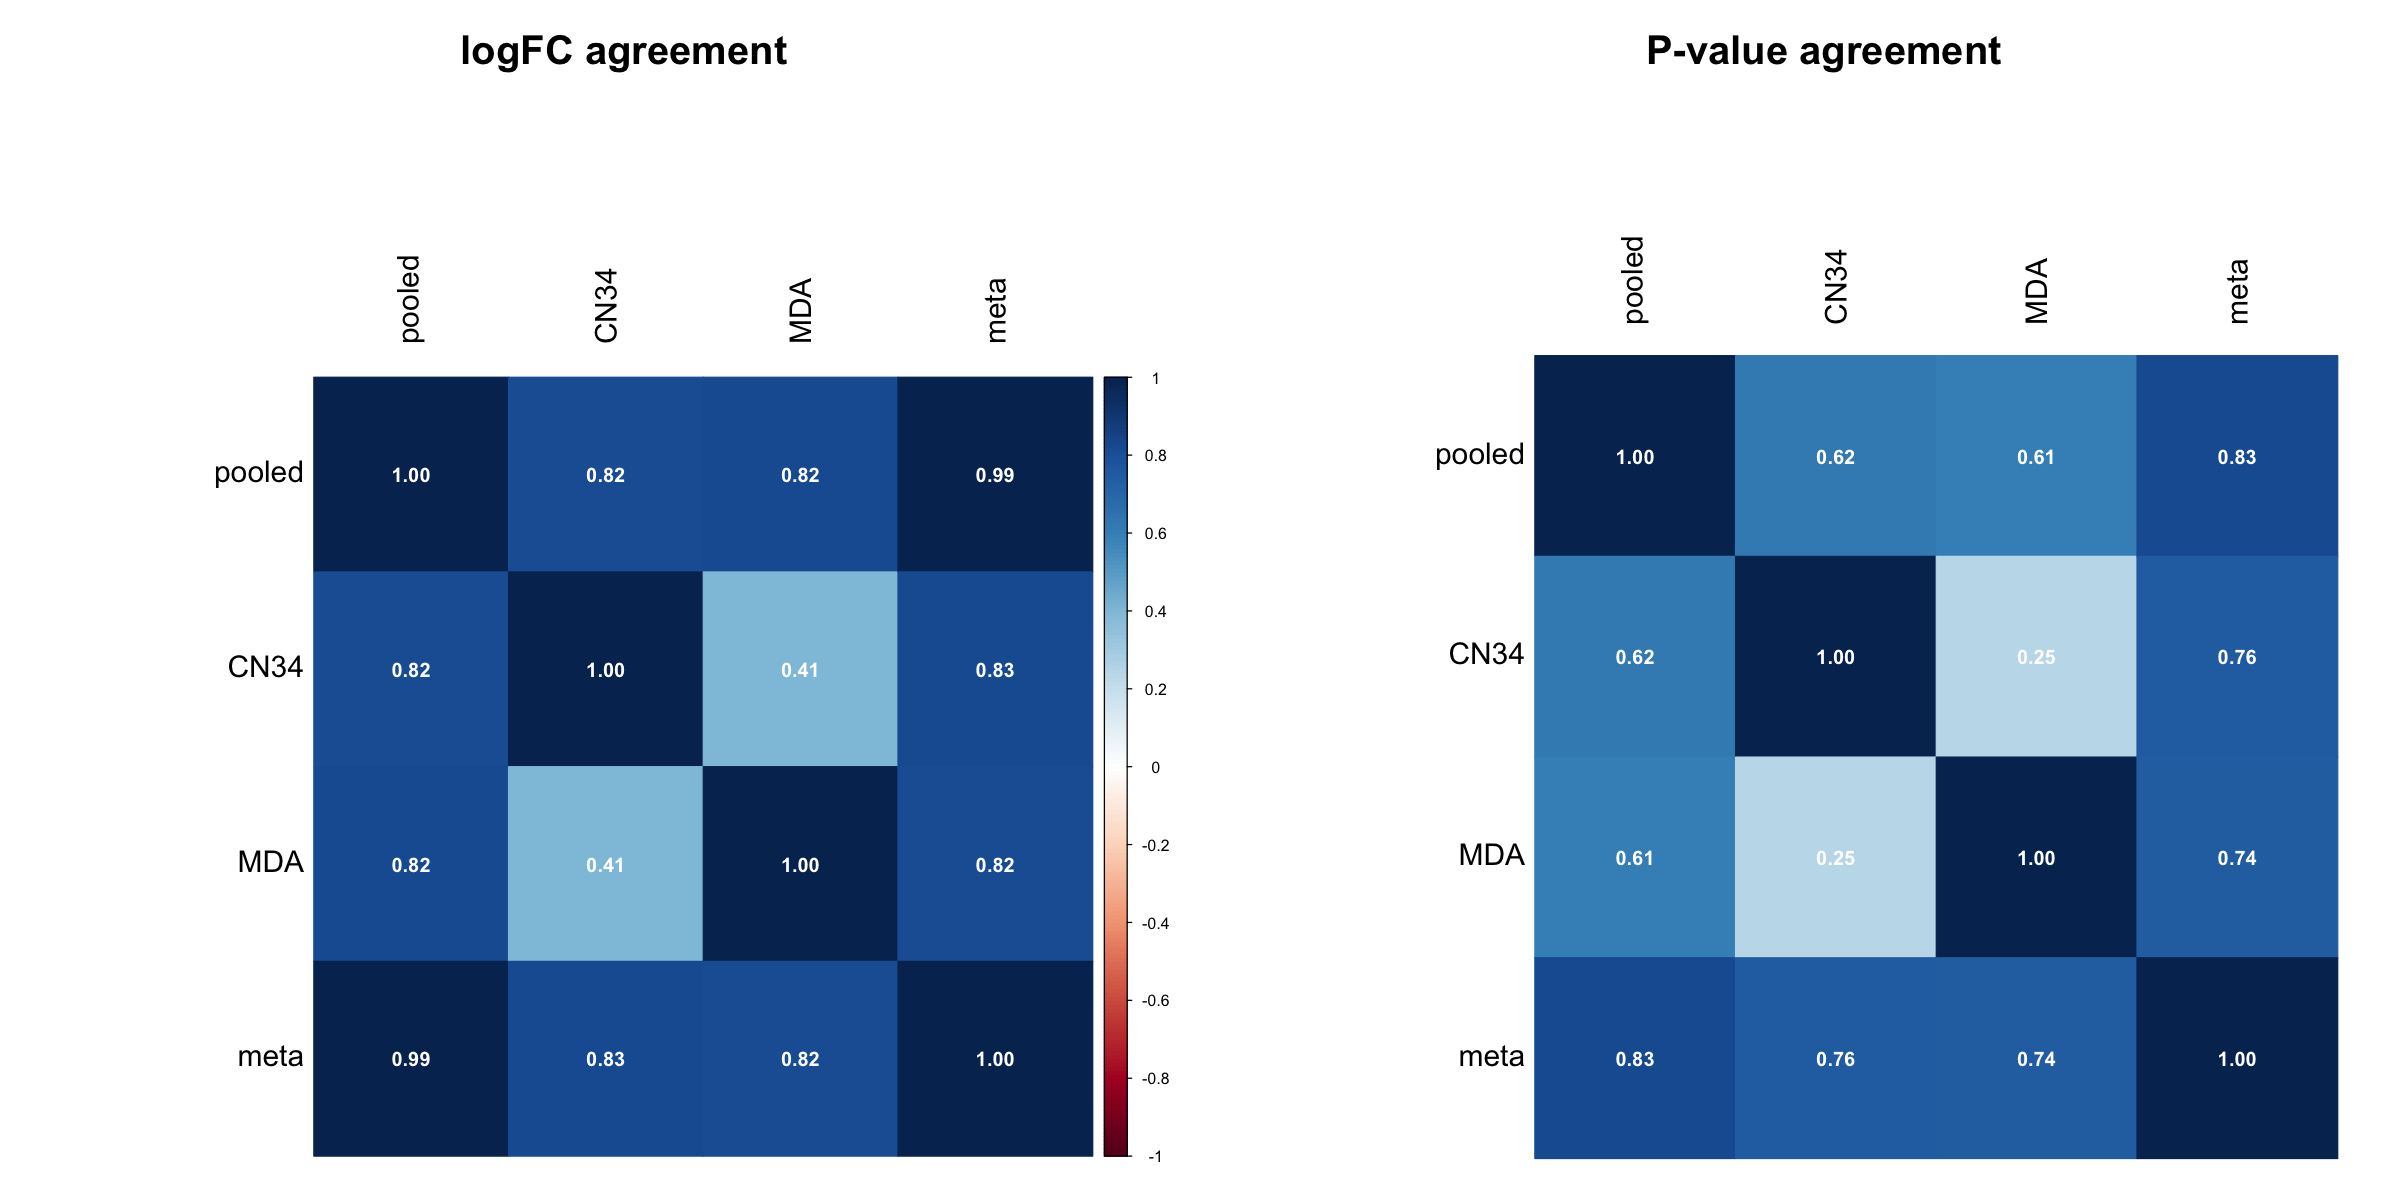

In [72]:
options(repr.plot.width = 20, repr.plot.height = 10)
visualize_meta_analysis(validation, 
                        beta_title = "logFC agreement",
                        p_title = "P-value agreement", 
                        label_size = 1.5, 
                        title_size = 2)

- If split and meta results closely track the pooled ones (high correlation, especially for effect size), meta-analysis is a reliable stand-in for pooling when raw data can't be combined directly.

### 5.3.2 Merging rep-by-rep test results

- It's also possible to combine rep-by-rep pairwise TER tests (e.g. A1 vs B1, A2 vs B1, A1 vs B2, A2 vs B2) rather than sub-datasets. This is wrapped into a single convenience function, `Ribolog::meta_analysis_hetero()`: it runs `TER_all_pairs()` on every replicate pair between the two groups you specify, keeps only the pairs comparing those two groups ("hetero" pairs), and combines them with `meta_test(..., comp_sym = TRUE)` (compound symmetry, appropriate since these are all equivalent measurements of the same contrast). It also fits a single pooled TER test on the same group_A/group_B samples for comparison. It returns a list with both: `rep_by_rep_meta` and `pooled_fit_pair` - see the empirical null / meta-analysis vignette (`vignettes/R_markdown/MODULE5_vignette.Rmd`, section 5.2.2) for the underlying step-by-step walkthrough.

- Set `groupID` as in Step 5.1 (the column defining which replicates are the same biological sample), and give it the two groups you want to compare - we'll reuse `CN34` and `LM1a`, the same pair used for the pooled TER test in Module 4.

In [73]:
groupID <- "cell_line"  # same grouping used in build_empirical_null (Step 5.1)
group_A <- "CN34"
group_B <- "LM1a"
uniqueID <- "replicate_name"  # e.g. a replicate name column, uniquely IDs each RNA/RPF pair

result <- Ribolog::meta_analysis_hetero(rr.v2[, -1], 
                                        sample_attributes,
                                        uniqueID = uniqueID, 
                                        groupID = groupID,
                                        group_A = group_A, 
                                        group_B = group_B,
                                        feature_list = as.vector(rr.v2$transcript))
rep_by_rep_meta <- result$rep_by_rep_meta
pooled_fit_pair <- result$pooled_fit_pair
head(rep_by_rep_meta)

While running the comparison for read_type ~ replicate_name, 6 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 2 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 8 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 2 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 9 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.
While running the comparison for read_type ~ replicate_name, 26 transcript(s) were removed because they had 0 counts across all the RPF samples being compared.


Warning message in Ribolog::meta_analysis_hetero(rr.v2[, -1], sample_attributes, :
“849 of 10543 transcripts were dropped from the meta-analysis because they were filtered out (e.g. 0 counts in one read type) in at least one rep-by-rep pair.”


                   CN34_r1_vs_LM1a_r1 CN34_r2_vs_LM1a_r1 CN34_r1_vs_LM1a_r2
CN34_r1_vs_LM1a_r1           1.000000          0.8507410          0.8283010
CN34_r2_vs_LM1a_r1           0.850741          1.0000000          0.6588532
CN34_r1_vs_LM1a_r2           0.828301          0.6588532          1.0000000
CN34_r2_vs_LM1a_r2           0.694342          0.8159629          0.8574243
                   CN34_r2_vs_LM1a_r2
CN34_r1_vs_LM1a_r1          0.6943420
CN34_r2_vs_LM1a_r1          0.8159629
CN34_r1_vs_LM1a_r2          0.8574243
CN34_r2_vs_LM1a_r2          1.0000000
[1] "Compound symmetry Rho: 0.675878386738463"


,meta_beta,meta_p
,<dbl>,<dbl>
ENST00000000233,0.2476412,1.867525e-02
ENST00000000412,-0.1999727,1.910264e-01
ENST00000000442,0.2263767,3.315283e-01
ENST00000001008,0.3507789,7.354694e-05
ENST00000002165,0.1777491,9.122416e-02
ENST00000003100,-0.1550609,1.937199e-01


- Compare the merged rep-by-rep result to a single pooled TER test on the same samples - the same "gold standard" check as in 5.3.1 - with `visualize_meta_analysis_hetero`:

Warning message in cor.test.default(p_x, p_y, method = cor_method):
“cannot compute exact p-value with ties”


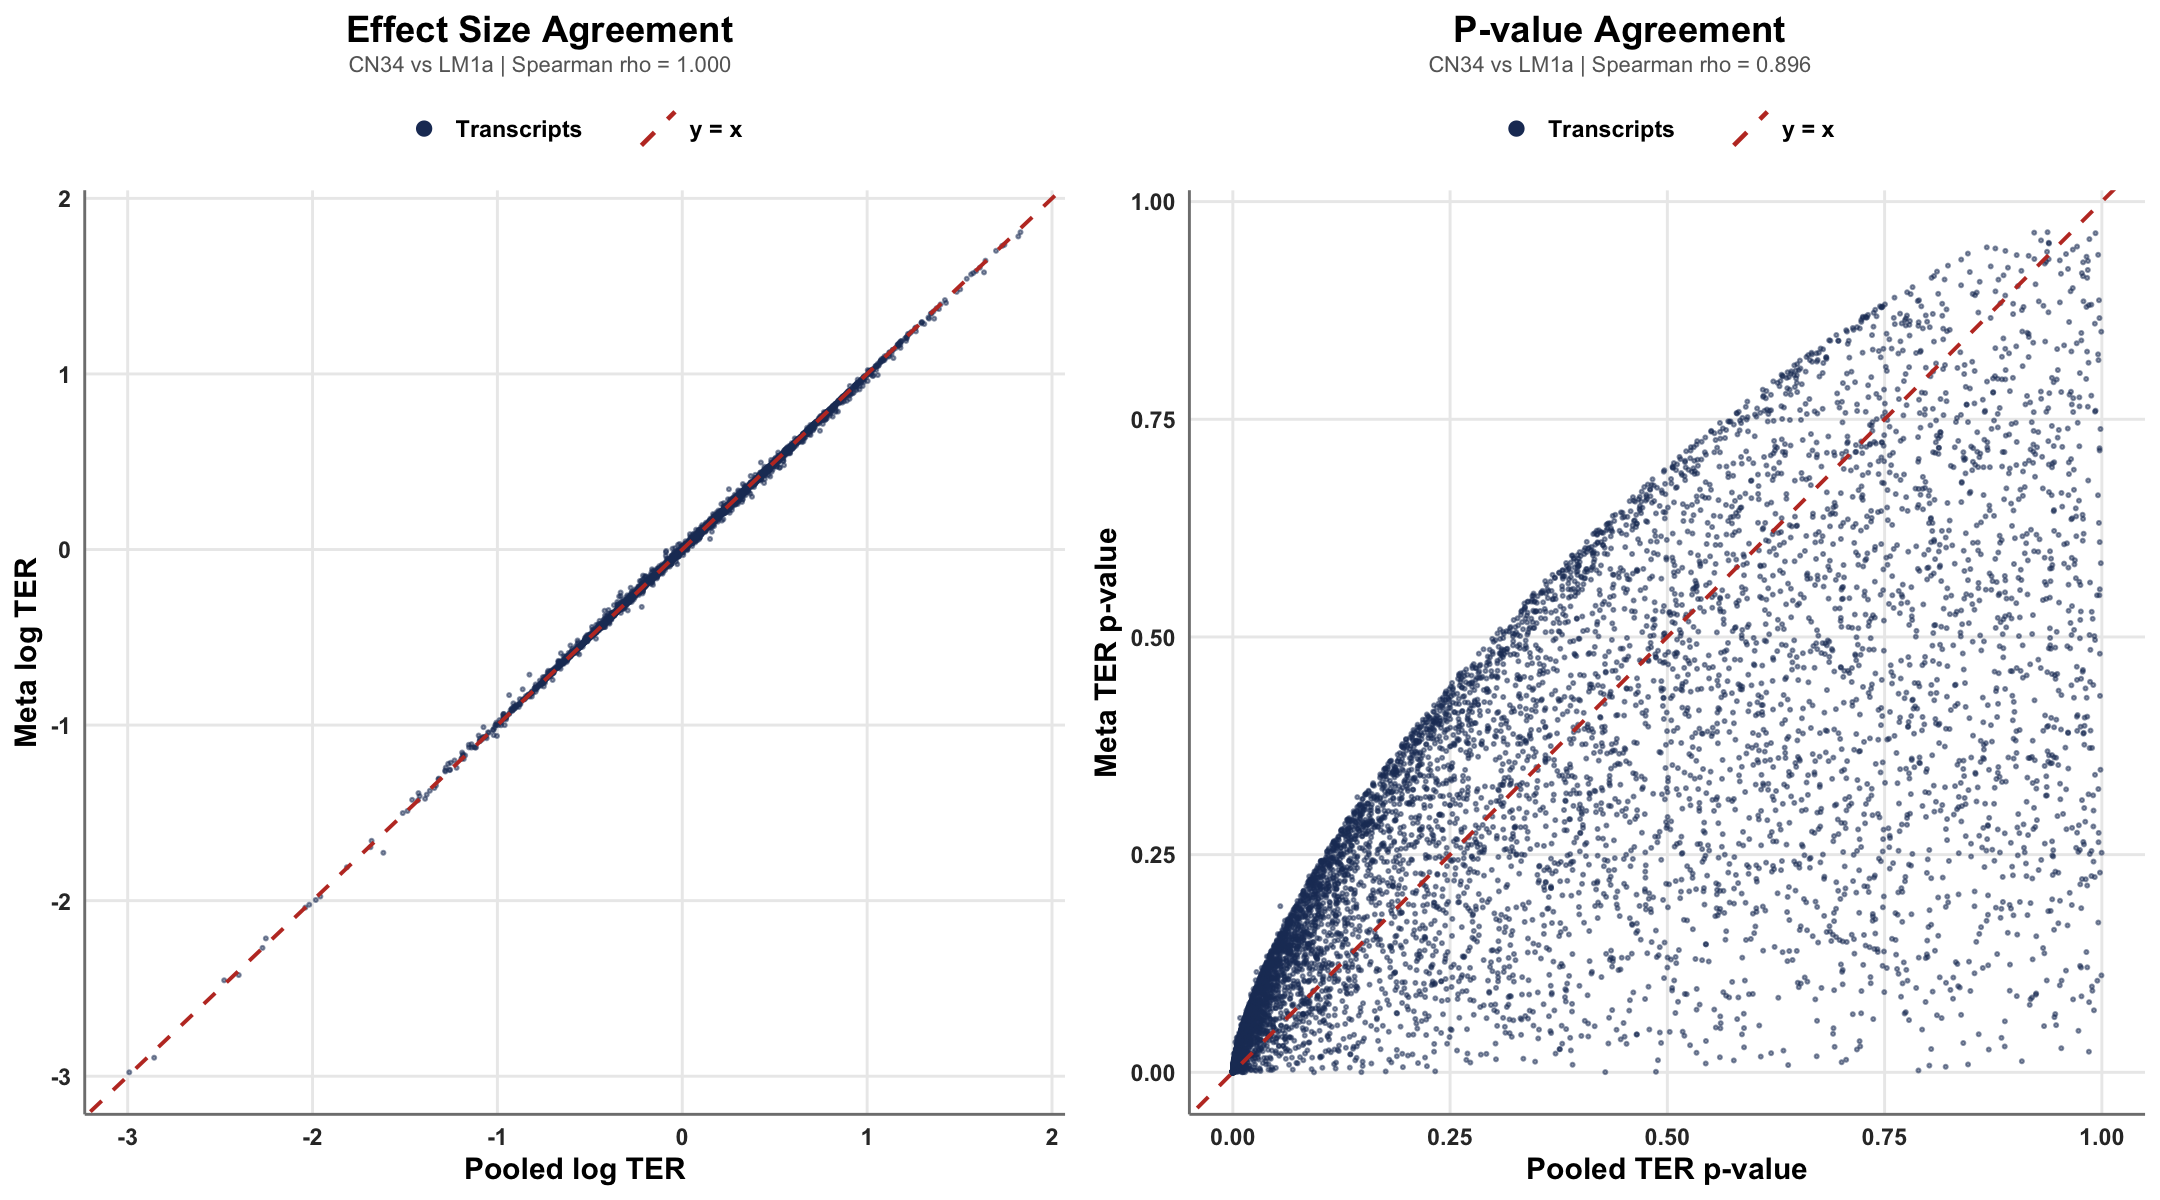

In [74]:
options(repr.plot.width = 18, repr.plot.height = 10)
visualize_meta_analysis_hetero(result, subtitle = "CN34 vs LM1a")

- As in 5.3.1, close agreement (especially in effect size) confirms that merging rep-by-rep pairwise tests is a valid alternative to pooling when the raw counts can't be combined directly (e.g. when only a subset of pairwise comparisons is usable).

# Module 6: Upstream ORF usage and stop codon readthrough

## Step 6.1: Get transcript read counts for different regions

- This module uses the original "reads_psite_list" ibject we created at the beginning of the notebook

In [75]:
reads_psite_list <- readRDS('reads_psite_list.RDS')

In [76]:
tr_regions_df <- get_tr_regions(reads_psite_list)

- The folllowing table gives us the counts of each UTR in each transcript for each sample

In [77]:
head(tr_regions_df)

sample_name,transcript,psite_region,count
<chr>,<fct>,<fct>,<int>
CN34_r1_rpf,ENST00000003084,cds,2
CN34_r1_rpf,ENST00000001146,3utr,4
CN34_r1_rpf,ENST00000001146,5utr,8
CN34_r1_rpf,ENST00000001146,cds,19
CN34_r1_rpf,ENST00000002125,3utr,2
CN34_r1_rpf,ENST00000002125,5utr,1


- Here is an example of the 5'UTR and 3'UTR transcript counts for a given gene "ENST00000001146"

In [78]:
tr_regions_df_LMCN_ENST00000001146 <- subset(tr_regions_df, transcript =="ENST00000001146")

In [79]:
print(tr_regions_df_LMCN_ENST00000001146)

    sample_name      transcript psite_region count
         <char>          <fctr>       <fctr> <int>
 1: CN34_r1_rpf ENST00000001146         3utr     4
 2: CN34_r1_rpf ENST00000001146         5utr     8
 3: CN34_r1_rpf ENST00000001146          cds    19
 4: CN34_r2_rpf ENST00000001146         3utr     7
 5: CN34_r2_rpf ENST00000001146         5utr    10
 6: CN34_r2_rpf ENST00000001146          cds    10
 7: LM1a_r1_rpf ENST00000001146         3utr     5
 8: LM1a_r1_rpf ENST00000001146         5utr     3
 9: LM1a_r1_rpf ENST00000001146          cds    15
10: LM1a_r2_rpf ENST00000001146         3utr     2
11: LM1a_r2_rpf ENST00000001146         5utr     4
12: LM1a_r2_rpf ENST00000001146          cds    12
13:  LM2_r1_rpf ENST00000001146          cds     8
14:  LM2_r2_rpf ENST00000001146          cds     9
15:  MDA_r1_rpf ENST00000001146         3utr     2
16:  MDA_r1_rpf ENST00000001146         5utr     2
17:  MDA_r1_rpf ENST00000001146          cds    11
18:  MDA_r2_rpf ENST00000001146

## Step 6.2: Normalisation and filtering

In [80]:
tr_regions_df_pivot_norm_clean <- normalize_and_clean(tr_regions_df)

[1] "Normalization factors:"
CN34_r1_rpf CN34_r2_rpf LM1a_r1_rpf LM1a_r2_rpf  LM2_r1_rpf  LM2_r2_rpf 
  2.3089307   2.8270559   1.0536243   1.0945210   0.8514517   0.9098464 
 MDA_r1_rpf  MDA_r2_rpf 
  1.4564753   1.0243692 
[1] "Number of records filtered out: 50958"


In [81]:
head(tr_regions_df_pivot_norm_clean)

transcript,sample_name,psite_region,count
<fct>,<chr>,<chr>,<dbl>
ENST00000001146,CN34_r1_rpf,cds,8.228918
ENST00000001146,CN34_r1_rpf,3utr,1.732404
ENST00000001146,CN34_r1_rpf,5utr,3.464807
ENST00000001146,CN34_r2_rpf,cds,3.537249
ENST00000001146,CN34_r2_rpf,3utr,2.476074
ENST00000001146,CN34_r2_rpf,5utr,3.537249


## Step 6.3: Fitting a multinomial logistic regression model

In [82]:
head(sample_attributes)

,sample_name,read_type,lung_metastasis,cell_line,replicate_no,replicate_name,cell_line_origin
,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>
1,CN34_r1_rna,RNA,N,CN34,1,CN34_r1,CN34
2,CN34_r2_rna,RNA,N,CN34,2,CN34_r2,CN34
3,LM1a_r1_rna,RNA,Y,LM1a,1,LM1a_r1,CN34
4,LM1a_r2_rna,RNA,Y,LM1a,2,LM1a_r2,CN34
5,LM2_r1_rna,RNA,Y,LM2,1,LM2_r1,MDA
6,LM2_r2_rna,RNA,Y,LM2,2,LM2_r2,MDA


In [83]:
multi_logit <- tr_region_multi_logit(data = tr_regions_df_pivot_norm_clean, 
                                     model = psite_region~lung_metastasis, 
                                     design=sample_attributes, 
                                     sample_ID='sample_name', 
                                     output = "short", 
                                     adj_method='fdr')

[1] "23.4110725916588% of transcripts had reads in <2 regions and were removed"
[1] "1701 transcripts were removed because there is less than 2 contrasting features in the variables of the model."


In [84]:
head(multi_logit[['3utr']])

,logFC_intercept,logFC_lung_metastasisY,pval_intercept,pval_lung_metastasisY,pval_corrected_intercept,pval_corrected_lung_metastasisY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENST00000001146,-1.506383,-0.4058891,1.282554e-03,0.51760019,1.641856e-03,0.7951801
ENST00000002125,-3.174741,1.3771706,4.194121e-09,0.03209304,6.950629e-09,0.1311912
ENST00000000233,-5.100149,0.5208588,0.000000e+00,0.22235114,0.000000e+00,0.4951713
ENST00000002829,-2.642545,-0.3548914,5.187199e-04,0.74114918,6.788148e-04,0.9546181
ENST00000001008,-4.253256,0.1181914,0.000000e+00,0.64464409,0.000000e+00,0.8852360
ENST00000002165,-3.312855,0.4013384,0.000000e+00,0.23339325,0.000000e+00,0.5096106


In [85]:
head(multi_logit[['5utr']])

,logFC_intercept,logFC_lung_metastasisY,pval_intercept,pval_lung_metastasisY,pval_corrected_intercept,pval_corrected_lung_metastasisY
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENST00000001146,-0.9903556,-0.9327646,9.707601e-03,0.100714646,1.237800e-02,0.253678709
ENST00000002125,-4.6868619,-11.7085270,3.497749e-05,0.980393138,5.157304e-05,1.000000000
ENST00000000233,-5.9062041,-0.5152950,0.000000e+00,0.542297857,0.000000e+00,0.835918050
ENST00000002829,-2.2878312,-0.2785857,4.025183e-04,0.755592955,5.552961e-04,1.000000000
ENST00000001008,-3.2790559,0.4871488,0.000000e+00,0.001057919,0.000000e+00,0.004729583
ENST00000002165,-4.0237796,0.4365309,0.000000e+00,0.354632992,0.000000e+00,0.634837447


In [86]:
mapper <- Ribolog::human_id_mapper

In [87]:
head(mapper)

,transcript,gene_id,gene_name
,<fct>,<fct>,<fct>
1,ENST00000003084,ENSG00000001626,CFTR
2,ENST00000001146,ENSG00000003137,CYP26B1
3,ENST00000002125,ENSG00000003509,NDUFAF7
4,ENST00000000233,ENSG00000004059,ARF5
5,ENST00000002829,ENSG00000001617,SEMA3F
6,ENST00000001008,ENSG00000004478,FKBP4


## Step 6.4: Visualize the usage of 3'UTR ANd 5'UTR in separate Volcano plots

### 3'UTR as a treatment vs CDS as control

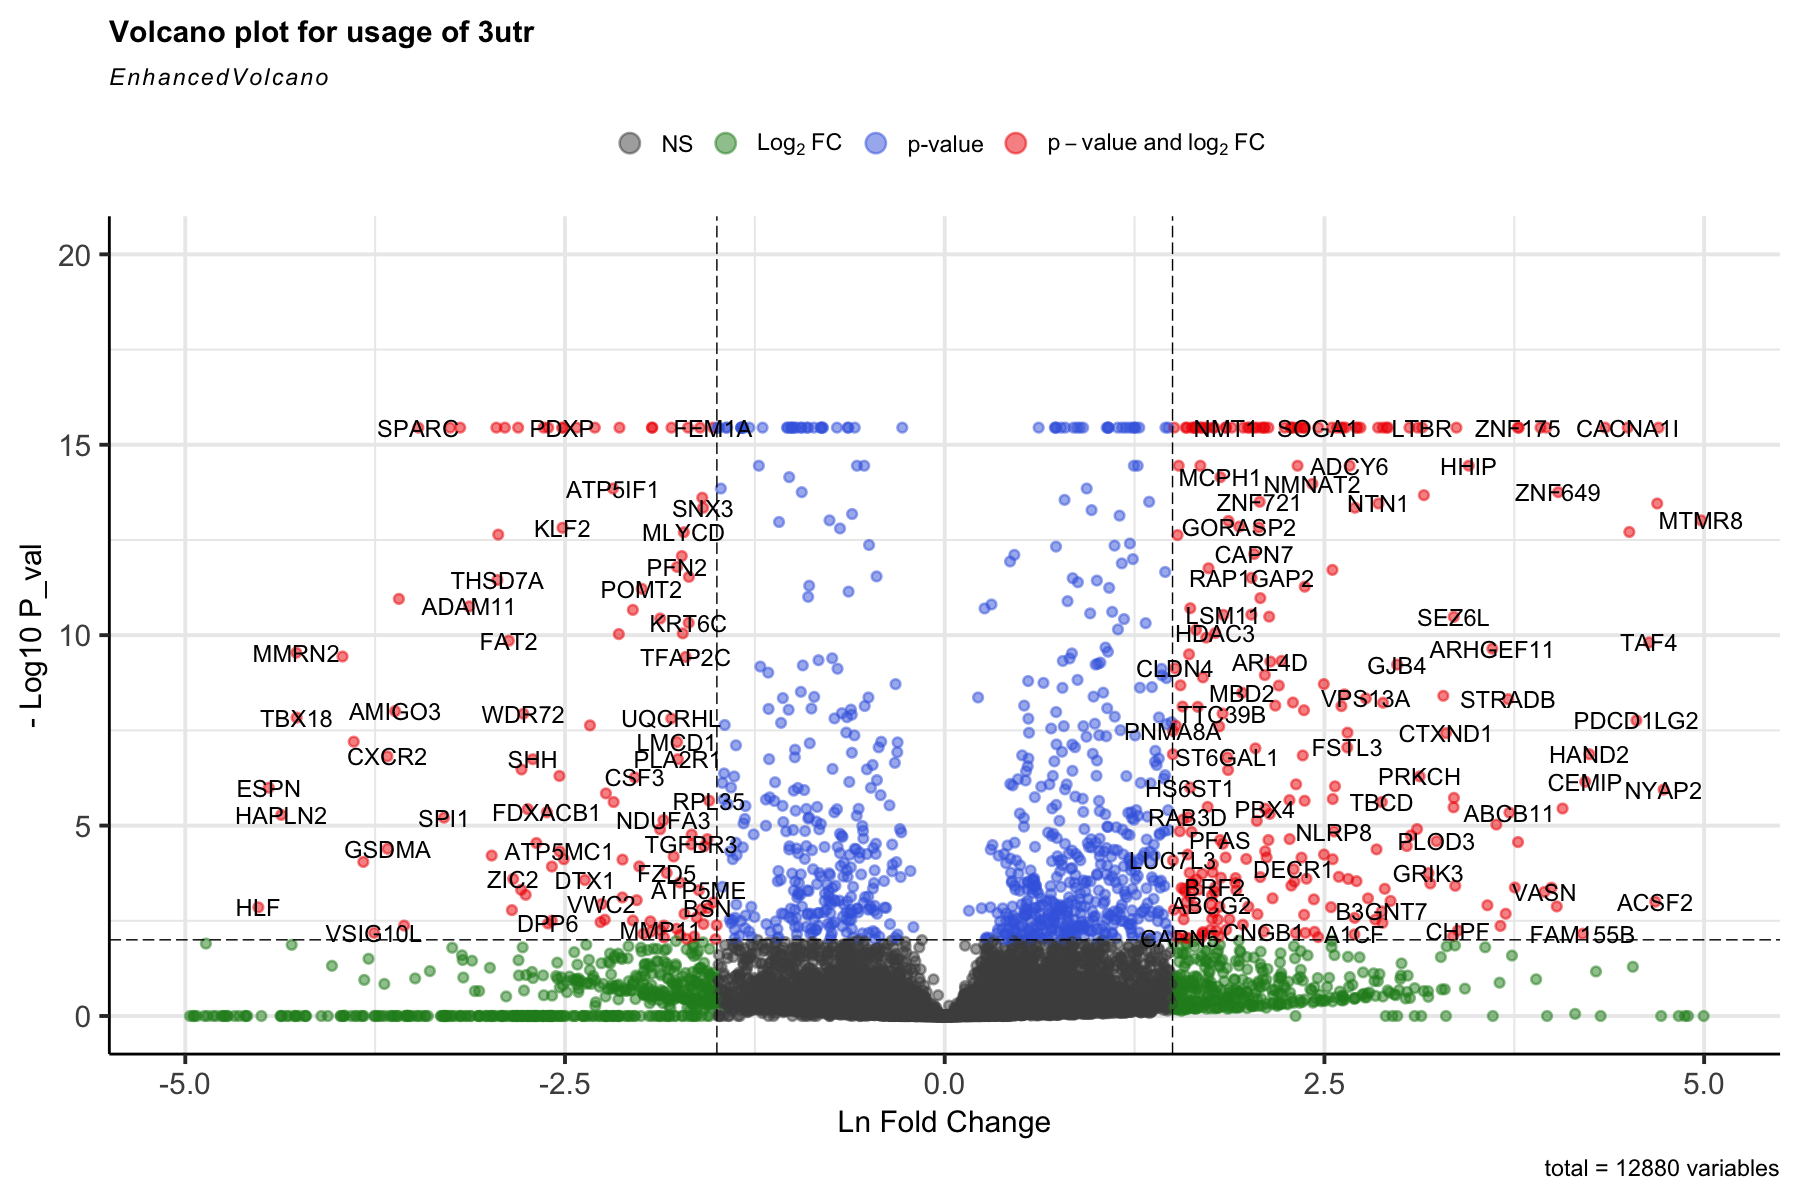

In [88]:
options(repr.plot.width = 15, repr.plot.height = 10)
visualize_orf_usage(multi_logit, 
                    log_fold_change='logFC_lung_metastasisY',
                    p_val_column='pval_corrected_lung_metastasisY', 
                    region='3utr',
                    ylim=c(0,20),
                    gene_mapper= mapper)

### 5'UTR as a treatment vs CDS as control

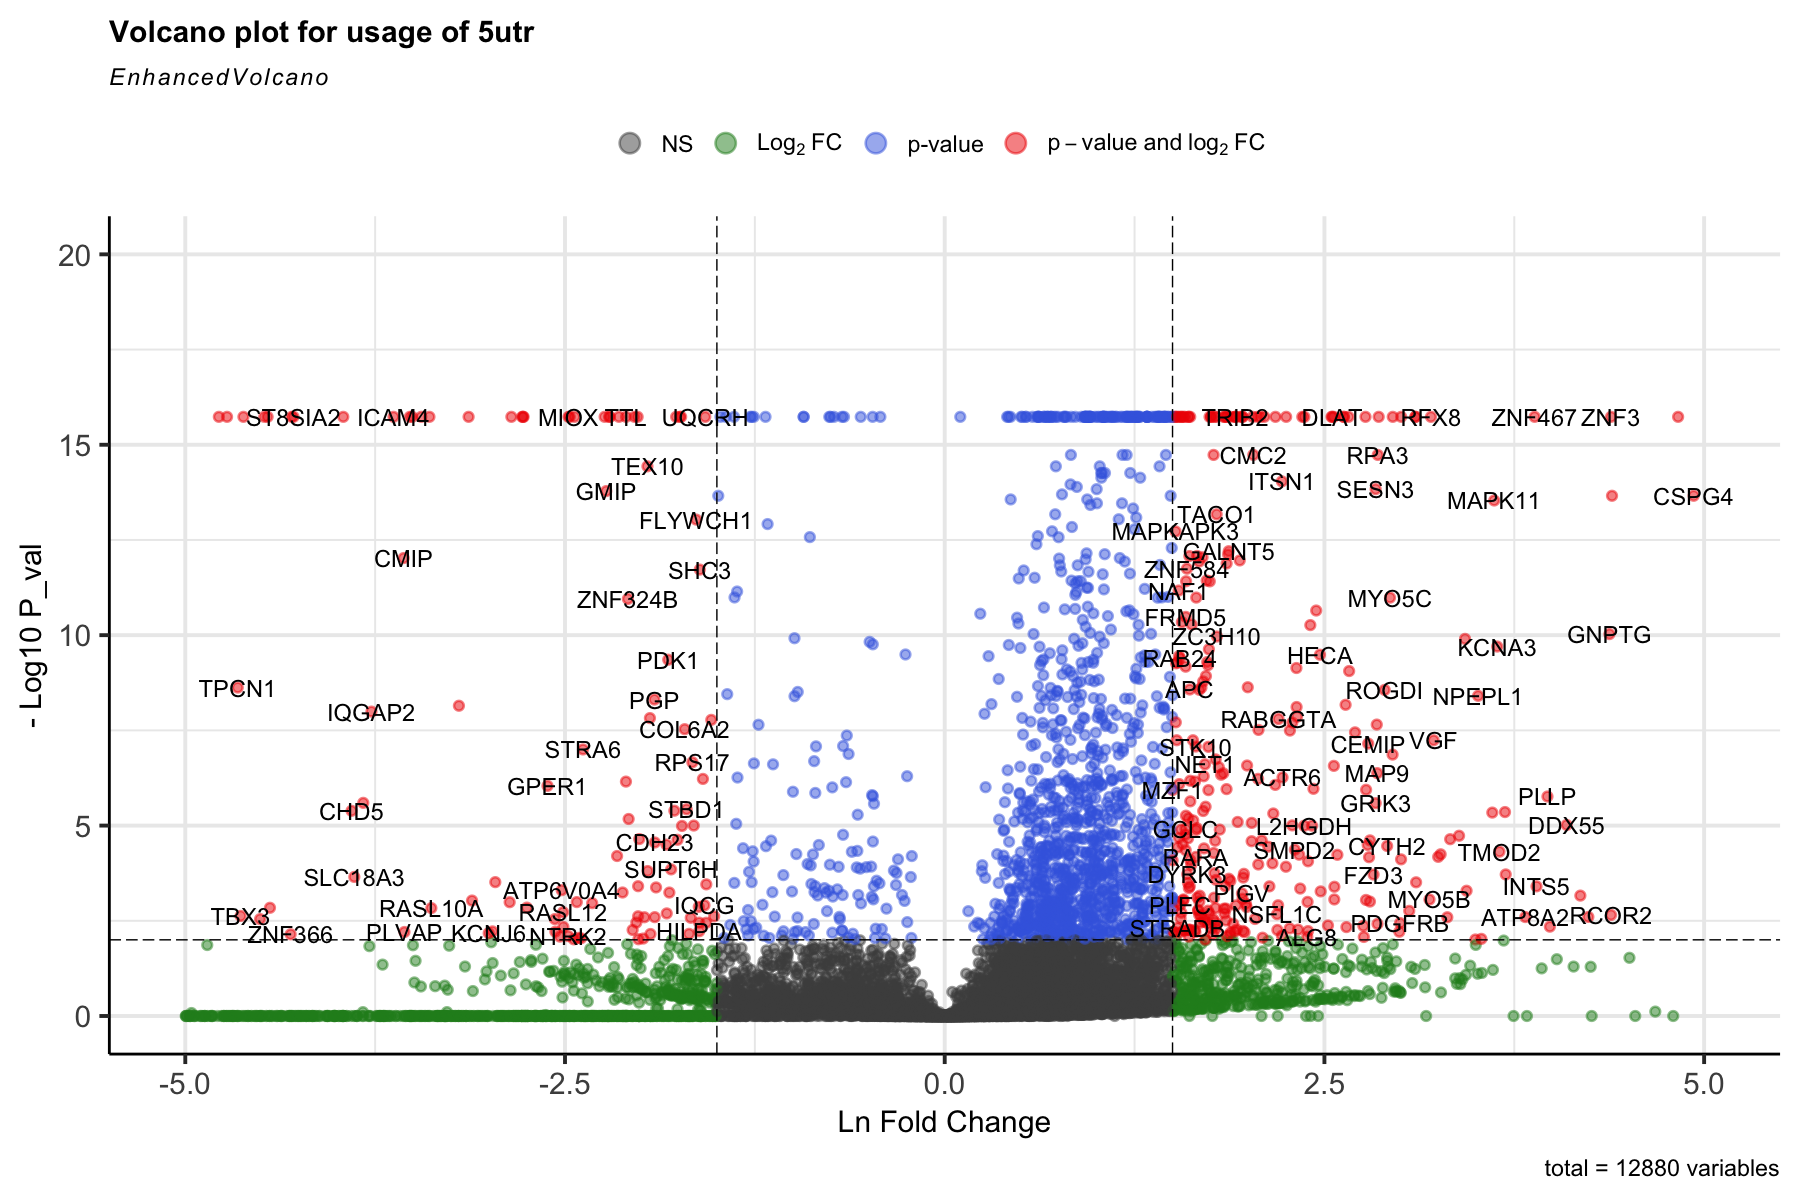

In [89]:
options(repr.plot.width = 15, repr.plot.height = 10)
visualize_orf_usage(multi_logit, 
                    log_fold_change='logFC_lung_metastasisY',
                    p_val_column='pval_corrected_lung_metastasisY', 
                    region='5utr',
                    ylim=c(0,20),
                    gene_mapper= mapper)